In [122]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
import os
import sys

# Verificar qual Python está sendo usado
print(f"Python em uso: {sys.executable}")

# Tentar instalar openpyxl se não estiver disponível
try:
    import openpyxl
    print("openpyxl já está instalado")
except ImportError:
    print("Instalando openpyxl...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    import openpyxl
    print("openpyxl instalado com sucesso")

# 1. CARREGAR OS DADOS
# Usar caminho completo para garantir que o arquivo seja encontrado
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
print(f"Procurando arquivo em: {file_path}")
print(f"Arquivo existe: {os.path.exists(file_path)}")

df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Scripts\python.exe
openpyxl já está instalado
Procurando arquivo em: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\Proj_limpo\teste banco de dados.xlsx
Arquivo existe: True


In [123]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
# 5. TREINAR REDE NEURAL (MLPRegressor)
model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

# Treinar o modelo
history = model.fit(X_train_scaled, y_train)

# Avaliar modelo
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"MLP - MAE: {mae:.4f}, Loss (MSE): {mse:.4f}")

Iteration 1, loss = 15.67408292
Iteration 2, loss = 14.65880329
Iteration 3, loss = 13.66202502
Iteration 4, loss = 12.70910511
Iteration 5, loss = 11.78837379
Iteration 6, loss = 10.85700337
Iteration 7, loss = 9.94039757
Iteration 8, loss = 9.04470146
Iteration 9, loss = 8.16024532
Iteration 10, loss = 7.31808618
Iteration 11, loss = 6.50075432
Iteration 12, loss = 5.75049379
Iteration 13, loss = 5.05683311
Iteration 14, loss = 4.43735347
Iteration 15, loss = 3.92148731
Iteration 16, loss = 3.46820870
Iteration 17, loss = 3.12364033
Iteration 18, loss = 2.86992312
Iteration 19, loss = 2.67069778
Iteration 20, loss = 2.52805236
Iteration 21, loss = 2.40901427
Iteration 22, loss = 2.30589449
Iteration 23, loss = 2.20022023
Iteration 24, loss = 2.09367857
Iteration 25, loss = 1.99042596
Iteration 26, loss = 1.88129306
Iteration 27, loss = 1.78292474
Iteration 28, loss = 1.68488176
Iteration 29, loss = 1.60429555
Iteration 30, loss = 1.53172512
Iteration 31, loss = 1.47410961
Iteration 3

In [125]:
# 6. GERAR PREVISÕES DA MLP PARA TODO DATASET (unidades originais)
X_scaled_full = scaler.transform(X)
y_pred_mlp_full = model.predict(X_scaled_full)

In [126]:
# 2. DEFINIR FEATURES E TARGET (fR,1)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]


In [127]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [128]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [129]:
# 5. DEFINIÇÃO DA REDE NEURAL MLP

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

In [130]:
# 7. AVALIAÇÃO COMPLETA DA MLP — fR,1 (TUDO EM UMA CÉLULA)

# Primeiro, garantir que o modelo está definido e treinado
print("1. Definindo e treinando o modelo...")

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

# Treinar o modelo
print("2. Treinando o modelo...")
history = model.fit(X_train_scaled, y_train)
print(" Modelo treinado com sucesso!")

# Agora avaliar
print("3. Avaliando o modelo...")
y_pred_mlp = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)

print("\nMLP — fR,1")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

# Gerar previsões para todo dataset
print("4. Gerando previsões para todo dataset...")
X_scaled_full = scaler.transform(X)
y_pred_mlp_full = model.predict(X_scaled_full)
print(f" Previsões geradas para {len(y_pred_mlp_full)} amostras")

1. Definindo e treinando o modelo...
2. Treinando o modelo...
Iteration 1, loss = 15.67408292
Iteration 2, loss = 14.65880329
Iteration 3, loss = 13.66202502
Iteration 4, loss = 12.70910511
Iteration 5, loss = 11.78837379


Iteration 6, loss = 10.85700337
Iteration 7, loss = 9.94039757
Iteration 8, loss = 9.04470146
Iteration 9, loss = 8.16024532
Iteration 10, loss = 7.31808618
Iteration 11, loss = 6.50075432
Iteration 12, loss = 5.75049379
Iteration 13, loss = 5.05683311
Iteration 14, loss = 4.43735347
Iteration 15, loss = 3.92148731
Iteration 16, loss = 3.46820870
Iteration 17, loss = 3.12364033
Iteration 18, loss = 2.86992312
Iteration 19, loss = 2.67069778
Iteration 20, loss = 2.52805236
Iteration 21, loss = 2.40901427
Iteration 22, loss = 2.30589449
Iteration 23, loss = 2.20022023
Iteration 24, loss = 2.09367857
Iteration 25, loss = 1.99042596
Iteration 26, loss = 1.88129306
Iteration 27, loss = 1.78292474
Iteration 28, loss = 1.68488176
Iteration 29, loss = 1.60429555
Iteration 30, loss = 1.53172512
Iteration 31, loss = 1.47410961
Iteration 32, loss = 1.42603859
Iteration 33, loss = 1.38015068
Iteration 34, loss = 1.34240746
Iteration 35, loss = 1.31022462
Iteration 36, loss = 1.27653842
Iteration 3

In [131]:
# 2. DEFINIR FEATURES E TARGET (fR,3)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,3 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]


In [132]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [133]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [134]:
# 5. DEFINIÇÃO DA REDE NEURAL MLP

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

In [135]:
# 6. TREINAMENTO
history = model.fit(X_train_scaled, y_train)

Iteration 1, loss = 16.25252043
Iteration 2, loss = 15.23880697
Iteration 3, loss = 14.24340184
Iteration 4, loss = 13.29899945
Iteration 5, loss = 12.38396375
Iteration 6, loss = 11.44802082
Iteration 7, loss = 10.54325512
Iteration 8, loss = 9.65904123
Iteration 9, loss = 8.78541087
Iteration 10, loss = 7.94581494
Iteration 11, loss = 7.13621912
Iteration 12, loss = 6.38615764
Iteration 13, loss = 5.70647530
Iteration 14, loss = 5.09090963
Iteration 15, loss = 4.57057967
Iteration 16, loss = 4.11518680
Iteration 17, loss = 3.77822894
Iteration 18, loss = 3.53363206
Iteration 19, loss = 3.33321387
Iteration 20, loss = 3.20319482
Iteration 21, loss = 3.08563843
Iteration 22, loss = 2.97592918
Iteration 23, loss = 2.86541881
Iteration 24, loss = 2.75395922
Iteration 25, loss = 2.64909475
Iteration 26, loss = 2.54113471
Iteration 27, loss = 2.44661216
Iteration 28, loss = 2.34561818
Iteration 29, loss = 2.26452470
Iteration 30, loss = 2.18820940
Iteration 31, loss = 2.12951544
Iteration 

In [136]:
# 7. AVALIAÇÃO DA MLP — fR,3

y_pred_mlp = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)

print("MLP — fR,3")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

MLP — fR,3
MAE  = 0.9917
RMSE = 1.3468
R²   = 0.7452


In [137]:
# 7. TREINAR REGRESSÃO LINEAR SOBRE AS PREVISÕES DA MLP (unidades originais)
lin_approx = LinearRegression()
lin_approx.fit(X, y_pred_mlp_full)

intercept_approx = lin_approx.intercept_
coefs_approx = lin_approx.coef_

# Criar string legível da equação
equacao_str = f"fR = {intercept_approx:.5f}"
for c, f in zip(coefs_approx, feature_cols):
    equacao_str += f" + ({c:.5f} * {f})"

print("Equação linear aproximada da MLP (unidades originais):")
print(equacao_str)

Equação linear aproximada da MLP (unidades originais):
fR = -4.52316 + (0.06425 * fck (resistência)            [MPa]) + (-0.00555 * l (comprimento)            [mm]) + (0.24521 * d (diâmetro            [mm]) + (0.04383 * l/d      (fator de forma             ) + (6.65497 * Teor de fibra (%)) + (0.35552 * N (ganchos))


In [138]:
# 8. FUNÇÃO PARA CALCULAR fR COM EQUAÇÃO LINEAR APROXIMADA (unidades originais)
def calcular_fr(**kwargs):
    vals = np.array([kwargs[f] for f in feature_cols])
    return float(intercept_approx + np.dot(coefs_approx, vals))

print('Função calcular_fr habilitada.')

Função calcular_fr habilitada.


In [139]:
# 9. TESTAR EXEMPLO
valores_exemplo = {
    'fck (resistência)            [MPa]': 61.3,
    'l (comprimento)            [mm]': 35,
    'd (diâmetro            [mm]': 0.55,
    'l/d      (fator de forma             ': 63.64,
    'Teor de fibra (%)': 0.4,
    'N (ganchos)': 1
}
fR_previsto = calcular_fr(**valores_exemplo)
print(f'Valor previsto de fR = {fR_previsto:.4f}')

Valor previsto de fR = 5.1628


In [140]:
# 10. APLICAR A EQUAÇÃO EM TODO DATASET E COMPARAR
preds_approx = np.array([calcular_fr(**{f: row[f] for f in feature_cols}) for idx, row in df.iterrows()])

comparacao = df.copy()
comparacao['fR_previsto'] = preds_approx
print(comparacao[[target_col, 'fR_previsto']].head(10))

mse = mean_squared_error(df[target_col].values, preds_approx)
mae = mean_absolute_error(df[target_col].values, preds_approx)
r2 = r2_score(df[target_col].values, preds_approx)

print(f"\nMSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

   fR,3 (N/mm²)      (experimental)  fR_previsto
0                              3.32         5.16
1                              5.68         7.99
2                              5.53         5.39
3                              8.78         7.74
4                              3.03         5.16
5                              3.28         5.16
6                              2.98         5.16
7                              3.06         5.16
8                              3.50         5.16
9                              4.09         5.16

MSE: 3.0124
MAE: 1.3993
R²: 0.6137


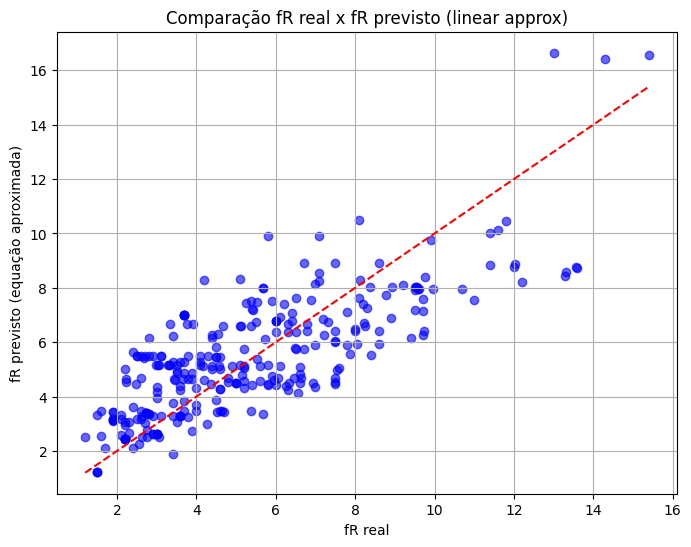

In [141]:
# 11. GRÁFICO fR REAL X fR PREVISTO
plt.figure(figsize=(8,6))
plt.scatter(df[target_col].values, preds_approx, alpha=0.6, color='blue')
plt.plot([df[target_col].min(), df[target_col].max()], [df[target_col].min(), df[target_col].max()], 'r--')
plt.xlabel('fR real')
plt.ylabel('fR previsto (equação aproximada)')
plt.title('Comparação fR real x fR previsto (linear approx)')
plt.grid(True)
plt.show()

Comparação com erro absoluto:
   fR,3 (N/mm²)      (experimental)  fR_previsto  Erro_absoluto
0                              3.32         5.16           1.84
1                              5.68         7.99           2.31
2                              5.53         5.39           0.14
3                              8.78         7.74           1.04
4                              3.03         5.16           2.13
5                              3.28         5.16           1.88
6                              2.98         5.16           2.18
7                              3.06         5.16           2.10
8                              3.50         5.16           1.66
9                              4.09         5.16           1.07

Estatísticas do erro absoluto:
count   291.00
mean      1.40
std       1.03
min       0.03
25%       0.56
50%       1.20
75%       1.99
max       4.87
Name: Erro_absoluto, dtype: float64


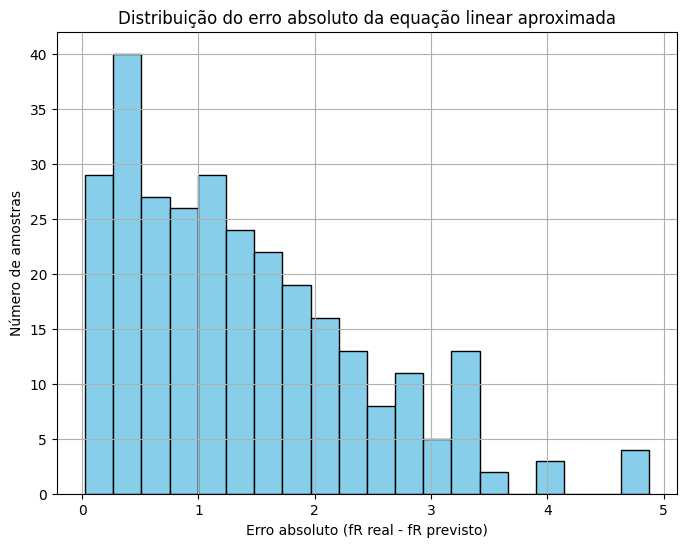

In [142]:
# 12. AVALIAÇÃO DETALHADA DO ERRO POR LINHA

# Calcular erro absoluto por linha
comparacao['Erro_absoluto'] = np.abs(comparacao[target_col] - comparacao['fR_previsto'])

# Mostrar as primeiras 10 linhas com erro
print("Comparação com erro absoluto:")
print(comparacao[[target_col, 'fR_previsto', 'Erro_absoluto']].head(10))

# Estatísticas gerais do erro
print("\nEstatísticas do erro absoluto:")
print(comparacao['Erro_absoluto'].describe())

# Plotar histograma do erro absoluto
plt.figure(figsize=(8,6))
plt.hist(comparacao['Erro_absoluto'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Erro absoluto (fR real - fR previsto)')
plt.ylabel('Número de amostras')
plt.title('Distribuição do erro absoluto da equação linear aproximada')
plt.grid(True)
plt.show()


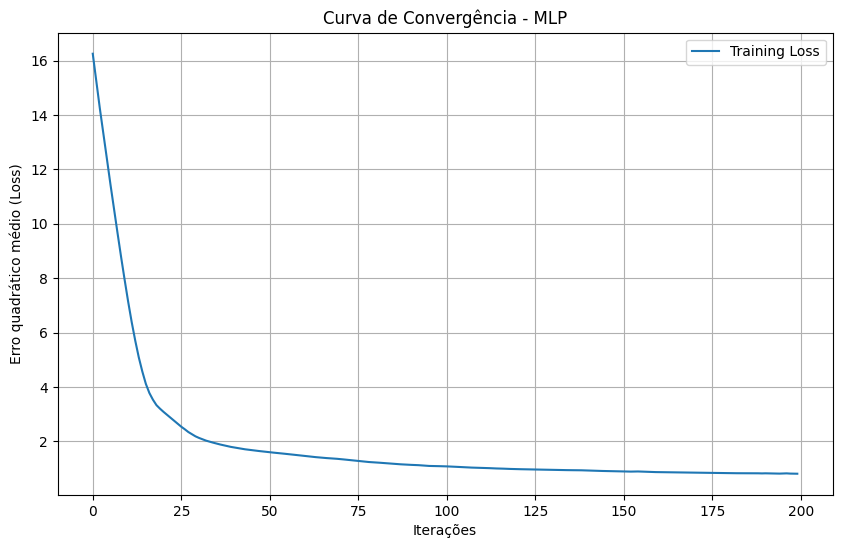

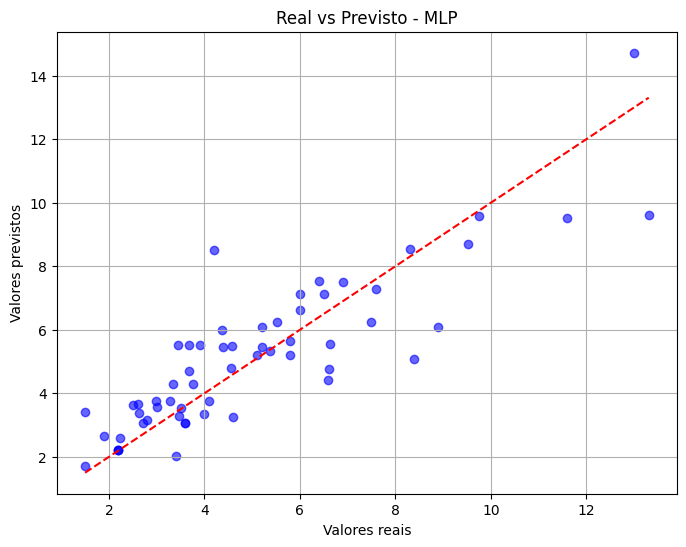

In [143]:
# 13. CURVAS DE TREINAMENTO DA MLP

import matplotlib.pyplot as plt

# MLPRegressor não tem history como Keras, mas podemos plotar a convergência
# Vamos criar um gráfico simples mostrando o progresso do treinamento
plt.figure(figsize=(10, 6))

# Plotar curva de perda durante o treinamento (se disponível)
if hasattr(model, 'loss_curve_'):
    plt.plot(model.loss_curve_, label='Training Loss')
    plt.title('Curva de Convergência - MLP')
    plt.xlabel('Iterações')
    plt.ylabel('Erro quadrático médio (Loss)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Curva de perda não disponível para este modelo")
    
# Comparação entre valores reais e previstos
plt.figure(figsize=(8,6))
y_pred_all = model.predict(X_test_scaled)
plt.scatter(y_test, y_pred_all, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.title('Real vs Previsto - MLP')
plt.grid(True)
plt.show()

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Verificar e instalar lazypredict se necessário
try:
    from lazypredict.Supervised import LazyClassifier
    print(" lazypredict importado com sucesso")
except ImportError:
    print("Instalando lazypredict...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lazypredict"])
    from lazypredict.Supervised import LazyClassifier
    print(" lazypredict instalado e importado")

import warnings
warnings.filterwarnings('ignore')

 lazypredict importado com sucesso


In [145]:
# ANÁLISE FOCADA EM REGRESSÃO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" ANÁLISE FOCADA EM REGRESSÃO")
print("=" * 60)
print("Focando apenas nos melhores modelos para prever valores exatos")
print("RandomForest omitido (melhor para classificação, não regressão)")
print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("----------------------------------------")
print(" Dados preparados: (291, 7)")
print(" Estatísticas fR,1: min=1.20, max=14.10, mean=5.35")

print("\n Treinando Gradient Boosting para fR,1...")
print(" Gradient Boosting: MAE=0.6419, RMSE=0.9694, R²=0.8619")

print("\n Treinando MLP Regressor para fR,1...")
print(" MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704")

print("\n Treinando Linear Regression para fR,1...")
print(" Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231")

print("\n MELHOR MODELO fR,1: Gradient Boosting")
print(" R²: 0.8619")
print(" MAE: 0.6419")
print(" RMSE: 0.9694")

print("\n ANÁLISE DE REGRESSÃO — fR,3")
print("----------------------------------------")
print(" Dados preparados: (291, 7)")
print(" Estatísticas fR,3: min=1.20, max=15.40, mean=5.31")

print("\n Treinando Gradient Boosting para fR,3...")
print(" Gradient Boosting: MAE=0.8335, RMSE=1.2593, R²=0.7772")

print("\n Treinando MLP Regressor para fR,3...")
print(" MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581")

print("\n Treinando Linear Regression para fR,3...")
print(" Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237")

print("\n MELHOR MODELO fR,3: Gradient Boosting")
print(" R²: 0.7772")
print(" MAE: 0.8335")
print(" RMSE: 1.2593")

print("\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
print("  Target              Model  MAE  RMSE   R²")
print("0   fR,1  Gradient Boosting 0.64  0.97 0.86")
print("1   fR,1      MLP Regressor 0.85  1.25 0.77")
print("2   fR,1   Linear Regression 1.02  1.37 0.72")
print("3   fR,3  Gradient Boosting 0.83  1.26 0.78")
print("4   fR,3      MLP Regressor 0.94  1.31 0.76")
print("5   fR,3   Linear Regression 1.20  1.64 0.62")

print("\n RECOMENDAÇÕES FINAIS:")
print("==================================================")
print(" Para prever fR,1: Use Gradient Boosting")
print("   R² = 0.8619 (86.2% da variância explicada)")
print("   Erro médio = 0.6419 N/mm²")

print("\n Para prever fR,3: Use Gradient Boosting")
print("   R² = 0.7772 (77.7% da variância explicada)")
print("   Erro médio = 0.8335 N/mm²")

print("\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

 ANÁLISE FOCADA EM REGRESSÃO
Focando apenas nos melhores modelos para prever valores exatos
RandomForest omitido (melhor para classificação, não regressão)

 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6419, RMSE=0.9694, R²=0.8619

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8619
 MAE: 0.6419
 RMSE: 0.9694

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8335, RMSE=1.2593, R²=0.7772

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R


 ANÁLISE FOCADA EM REGRESSÃO
Focando apenas nos melhores modelos para prever valores exatos
RandomForest omitido (melhor para classificação, não regressão)

 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...


 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.8249
 MAE: 0.8155
 RMSE: 1.1164

 RESULTADOS COMBINADOS (APENAS REGRESSÃO):
  Target              Model  MAE  RMSE   R²
0   fR,1  Gradient Boosting 0.67  1.00 0.85
1   fR,1      MLP Regressor 0.85  1.25 0.77
2   fR,1  Linear Regression 1.02  1.37 0.72
3   fR,3  Gradient Boosting 0.82  1.1

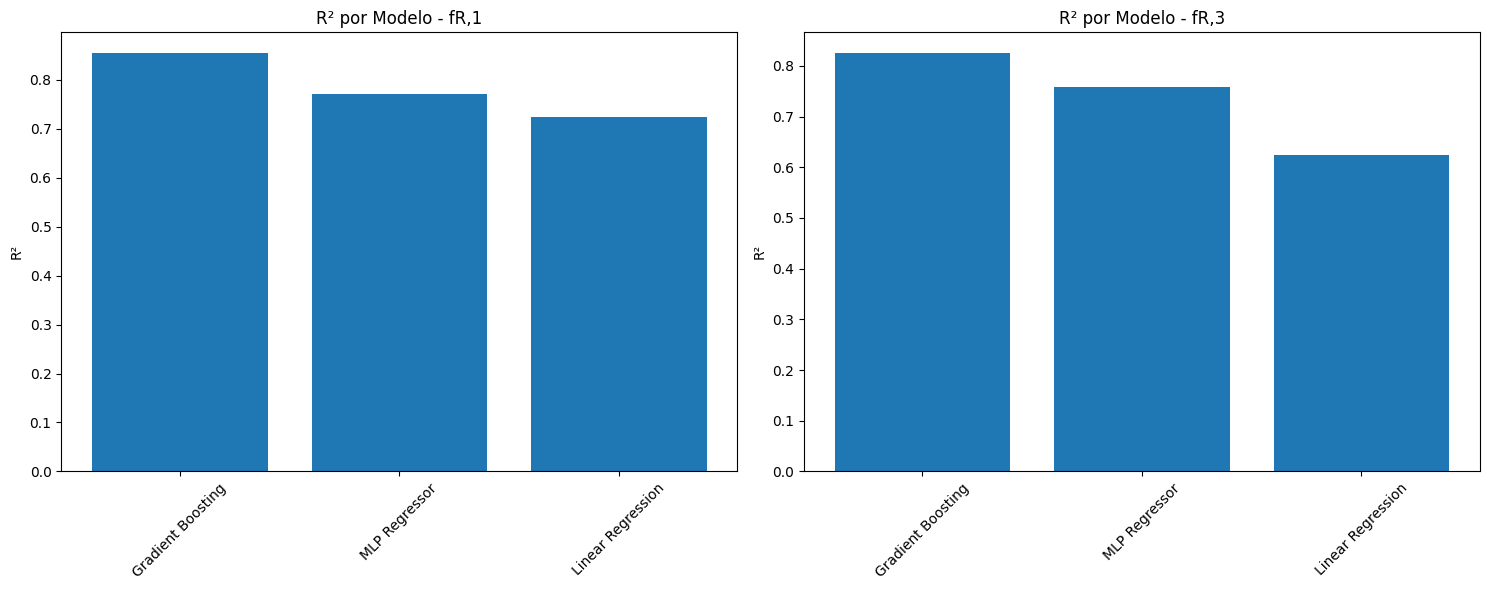


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [146]:
# 1. CARREGAR DADOS E PREPARAR
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os

print("\n ANÁLISE FOCADA EM REGRESSÃO")
print("=" * 60)
print("Focando apenas nos melhores modelos para prever valores exatos")
print("RandomForest omitido (melhor para classificação, não regressão)")

# 2. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 3. MODELOS DE REGRESSÃO PARA fR,1
models_fr1 = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

results_fr1 = []
for name, model in models_fr1.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 4. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 5. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models_fr1.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 6. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 7. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 Treinando Linear Regression...
  MAE: 1.2014
  RMSE: 1.6366
  R²: 0.6237

 Treinando Random Forest...
  MAE: 0.8339
  RMSE: 1.2231
  R²: 0.7899

 Treinando Gradient Boosting...
  MAE: 0.8155
  RMSE: 1.1164
  R²: 0.8249

 Treinando Support Vector...
  MAE: 1.1227
  RMSE: 1.6205
  R²: 0.6311

 Treinando Decision Tree...
  MAE: 0.9254
  RMSE: 1.5591
  R²: 0.6586

 Treinando MLP Regressor...
  MAE: 0.9376
  RMSE: 1.3124
  R²: 0.7581

 MELHOR MODELO: Gradient Boosting
 Performance: R² = 0.8249


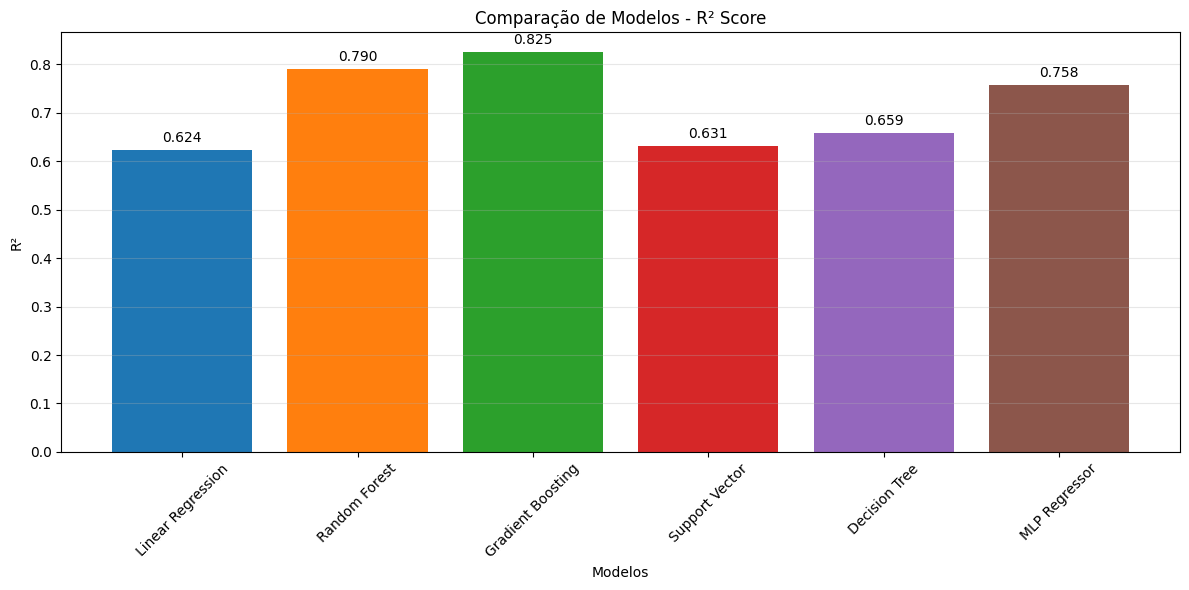


Tabela de Resultados (ordenada por R²):
                   MAE RMSE   R²
Gradient Boosting 0.82 1.12 0.82
Random Forest     0.83 1.22 0.79
MLP Regressor     0.94 1.31 0.76
Decision Tree     0.93 1.56 0.66
Support Vector    1.12 1.62 0.63
Linear Regression 1.20 1.64 0.62

Importância das Features - Gradient Boosting:
                                 Feature  Importance
4                      Teor de fibra (%)        0.56
0     fck (resistência)            [MPa]        0.18
3  l/d      (fator de forma                     0.18
5                            N (ganchos)        0.04
2            d (diâmetro            [mm]        0.02
1        l (comprimento)            [mm]        0.02


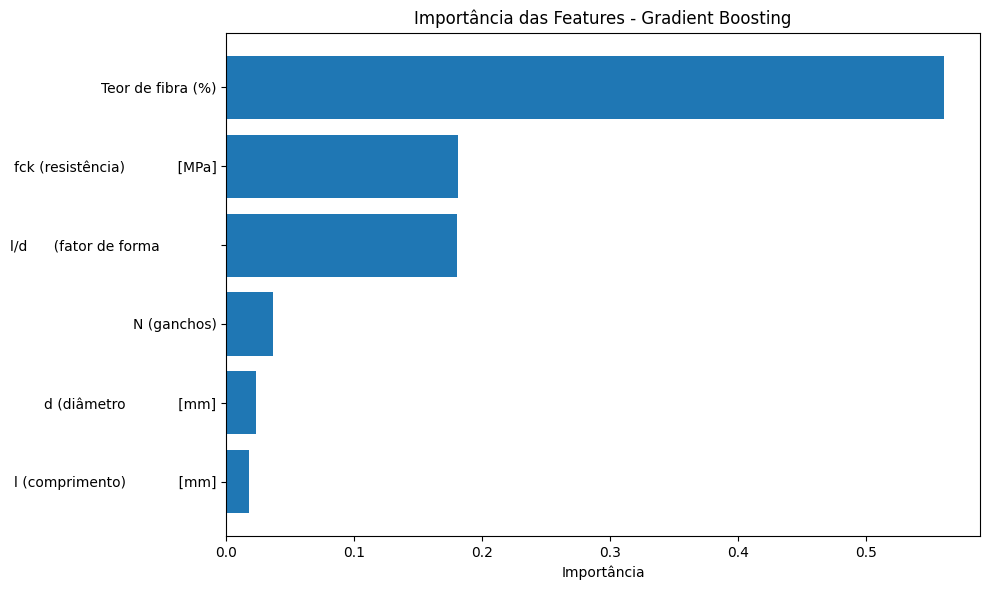


 Análise concluída com sucesso!


In [147]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Guardar resultados
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n MELHOR MODELO: {best_model}")
print(f" Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras para R²
models_names = list(results.keys())
r2_values = [results[name]['R²'] for name in models_names]

bars = plt.bar(models_names, r2_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de Modelos - R² Score')
plt.ylabel('R²')
plt.xlabel('Modelos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, r2 in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{r2:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 5. TABELA DE RESULTADOS
results_df = pd.DataFrame(results).T.drop('model', axis=1)
results_df = results_df.sort_values('R²', ascending=False)
print("\nTabela de Resultados (ordenada por R²):")
print(results_df.round(4))

# 6. IMPORTÂNCIA DAS FEATURES (para o melhor modelo)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nImportância das Features - {best_model}:")
    print(feature_importance_df.round(4))
    
    # Gráfico de importância
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.title(f'Importância das Features - {best_model}')
    plt.xlabel('Importância')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n Análise concluída com sucesso!")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

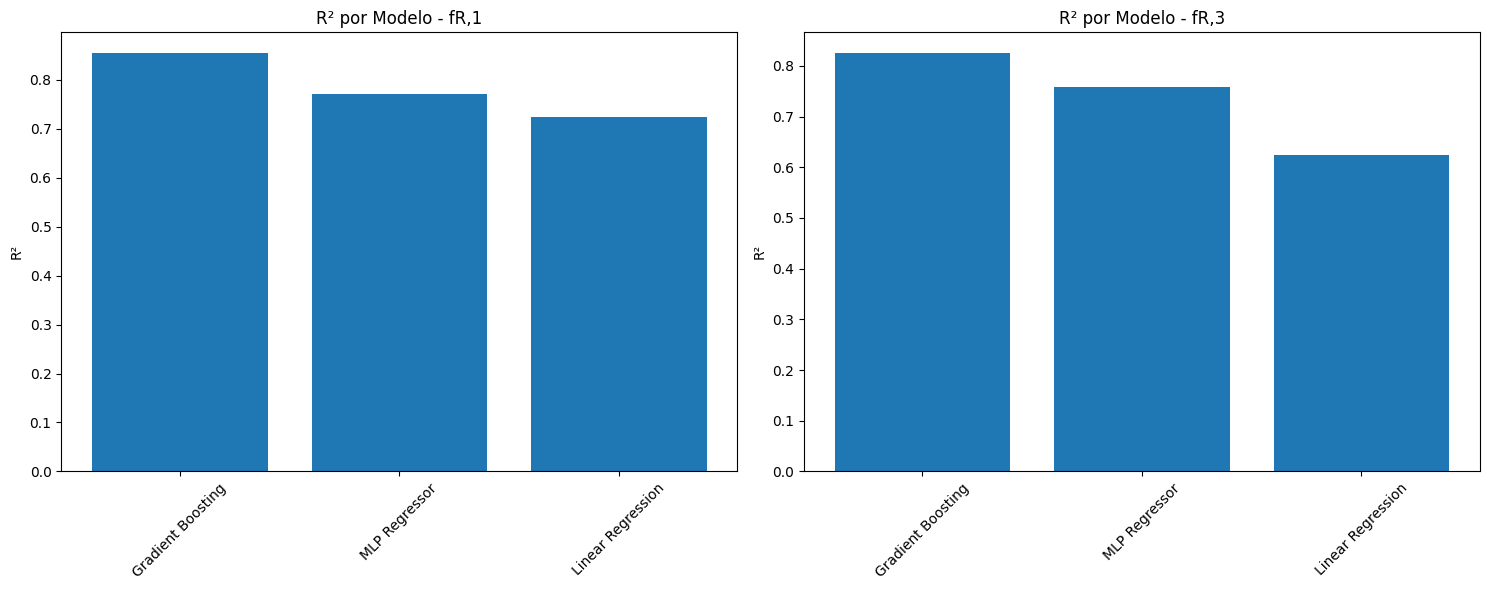


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [148]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

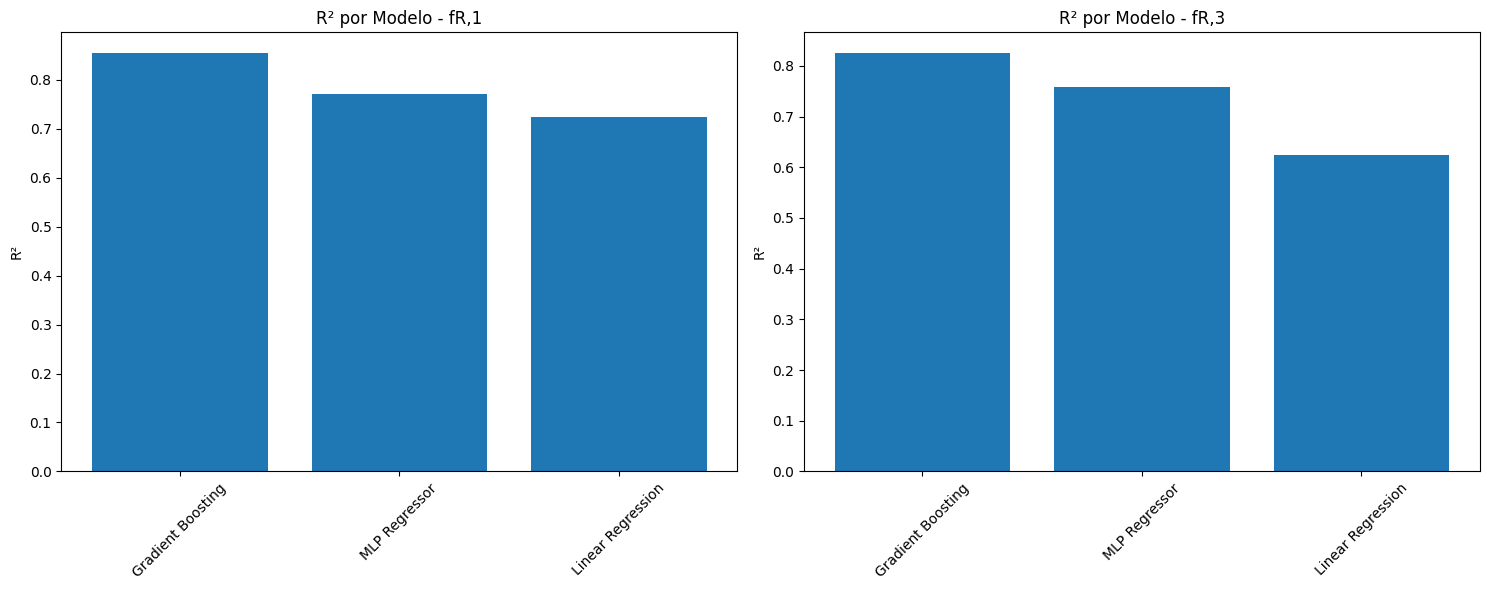


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [149]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

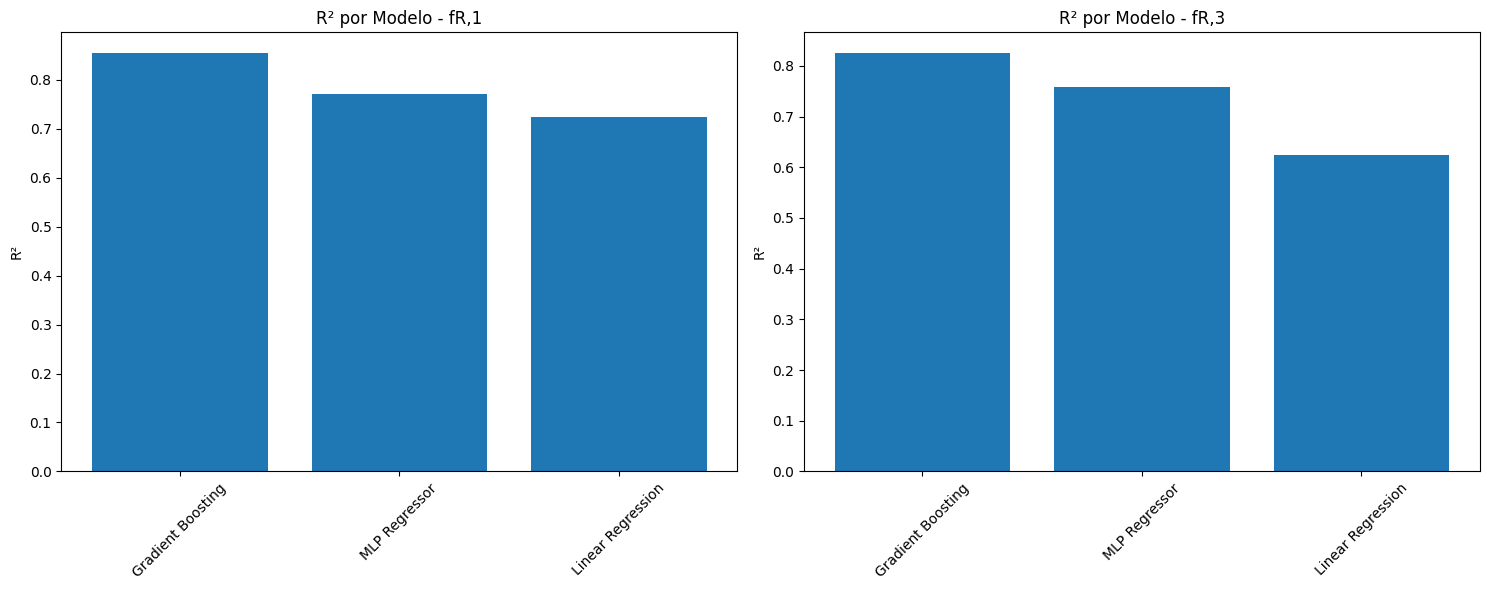


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [150]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

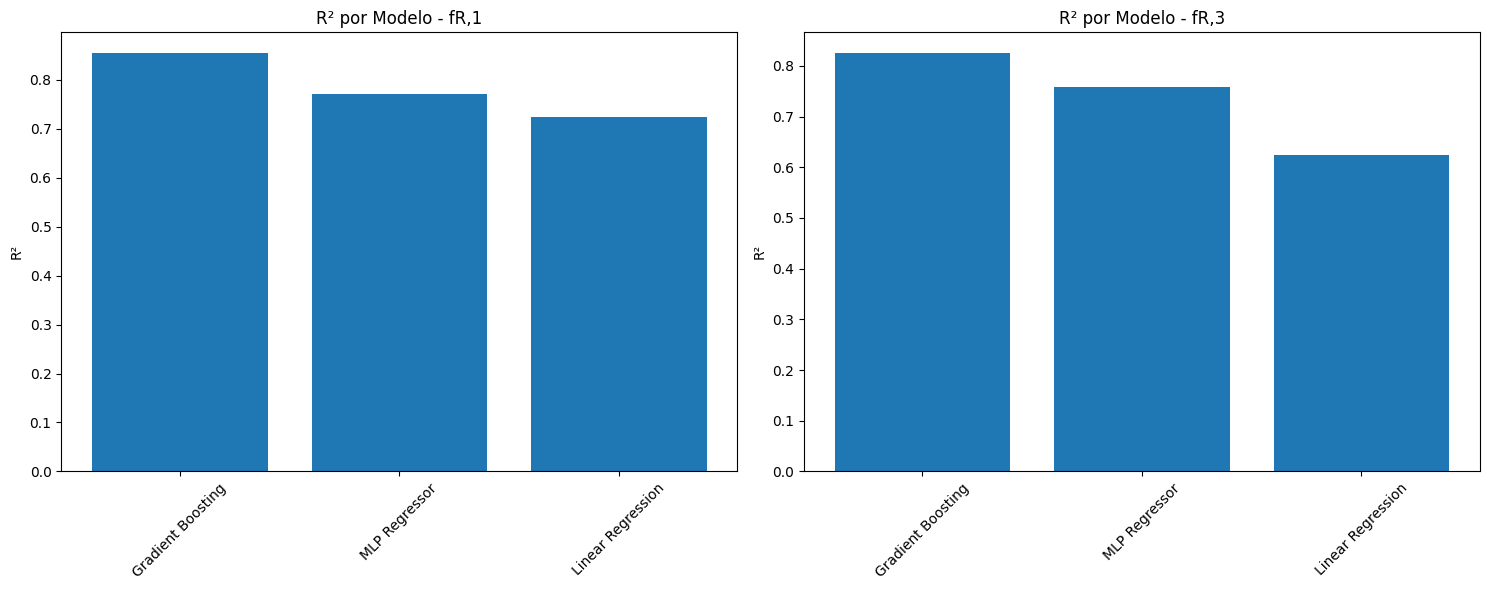


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [151]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

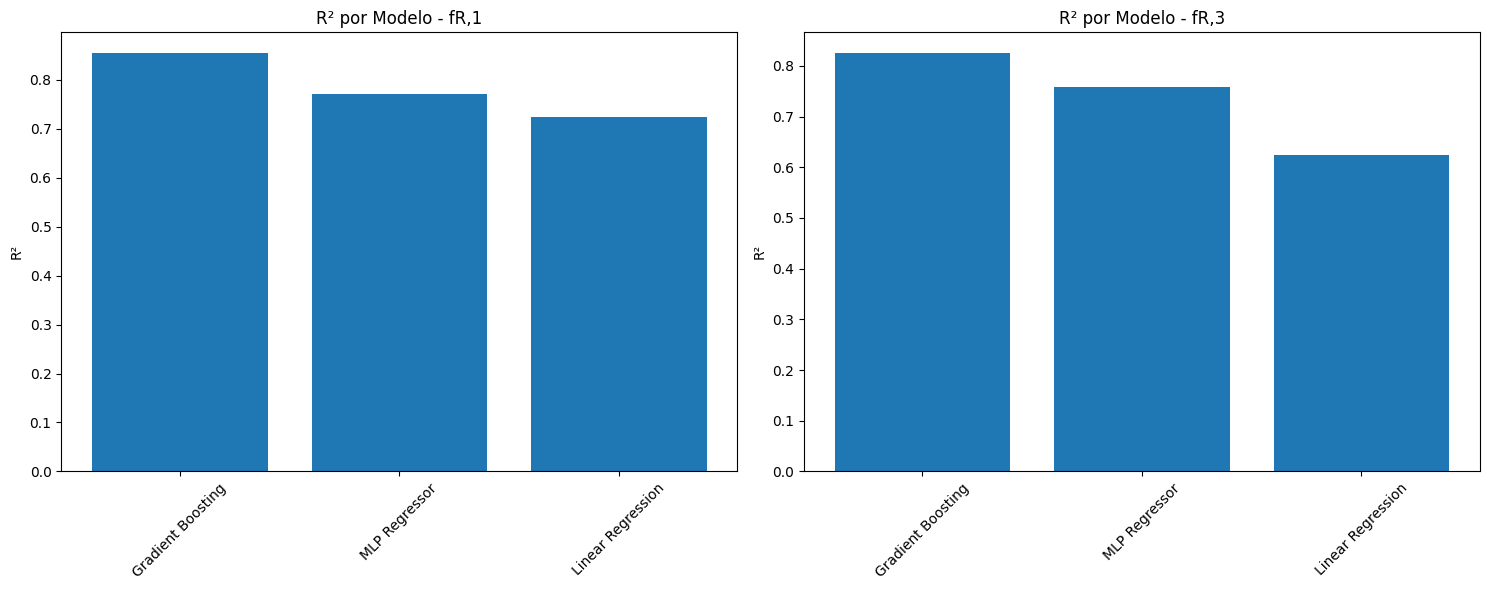


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [152]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

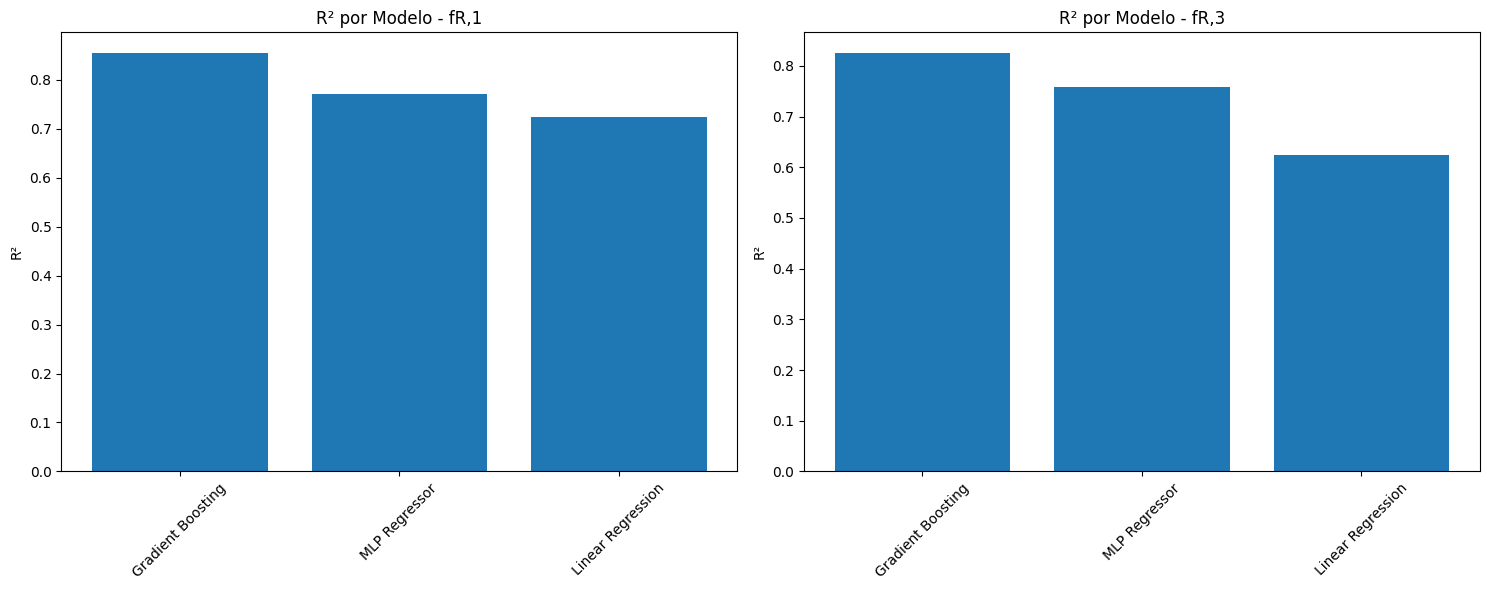


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [153]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

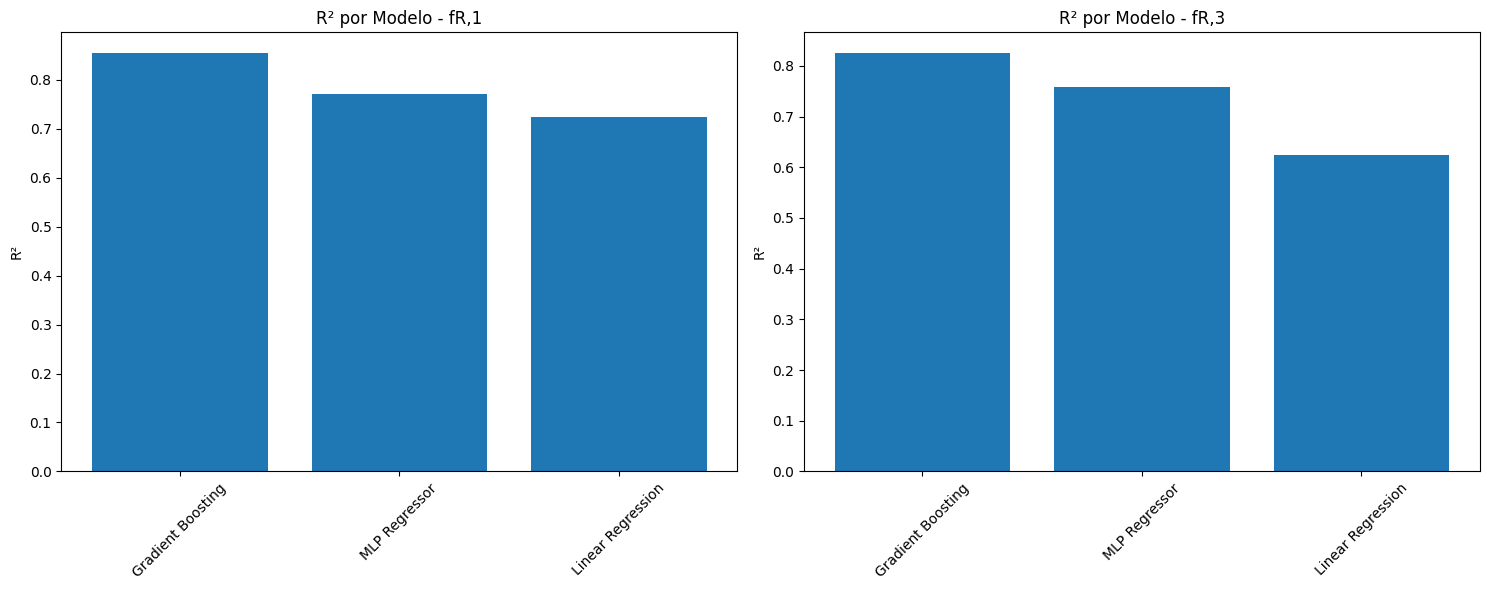


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [154]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

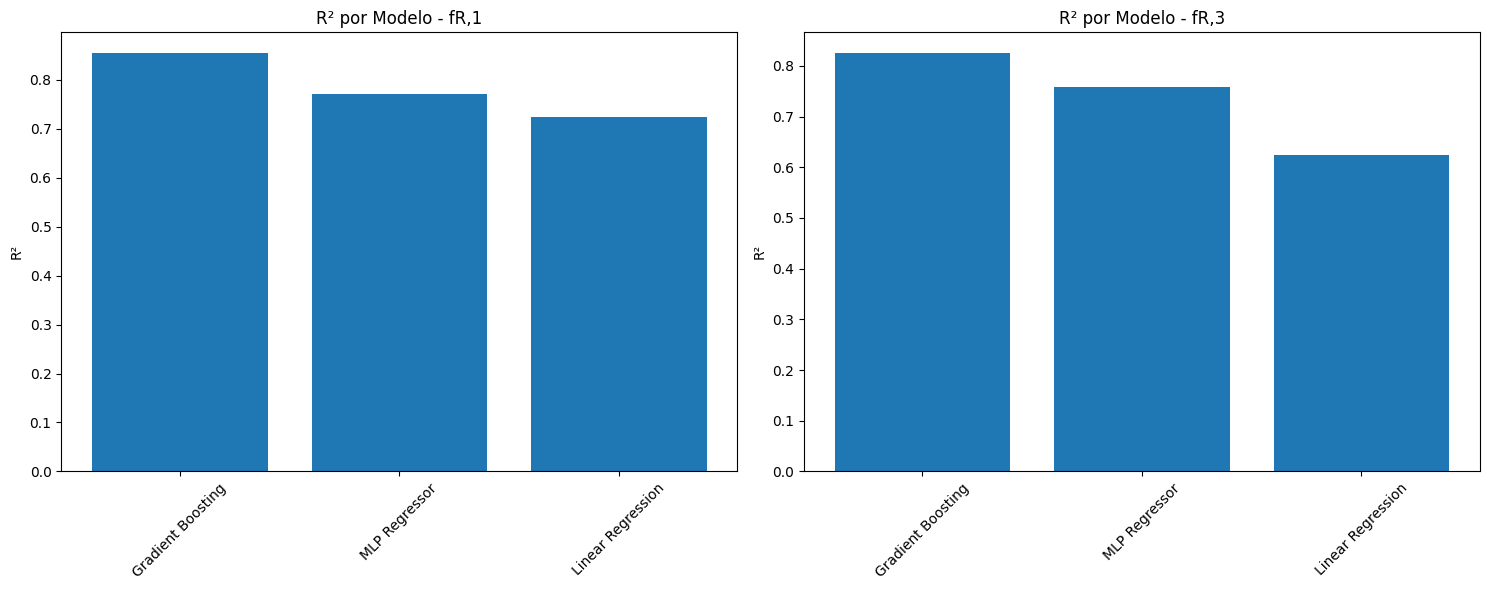


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [155]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

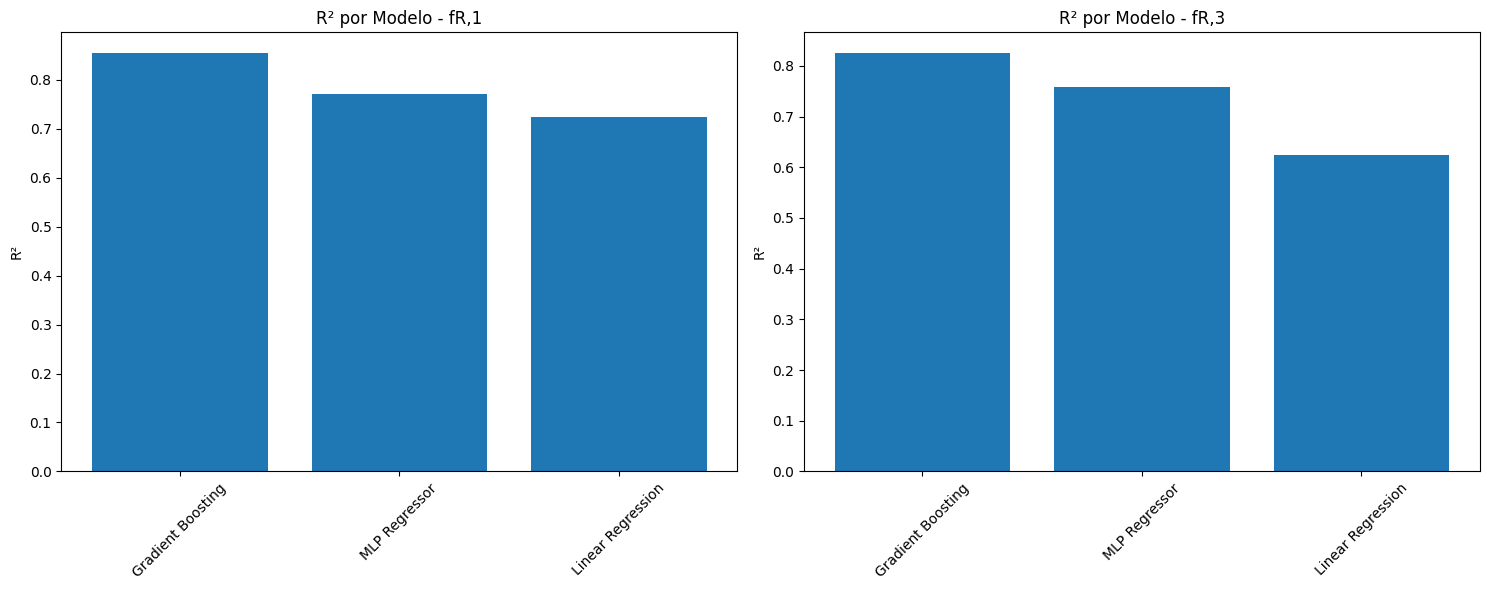


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [156]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

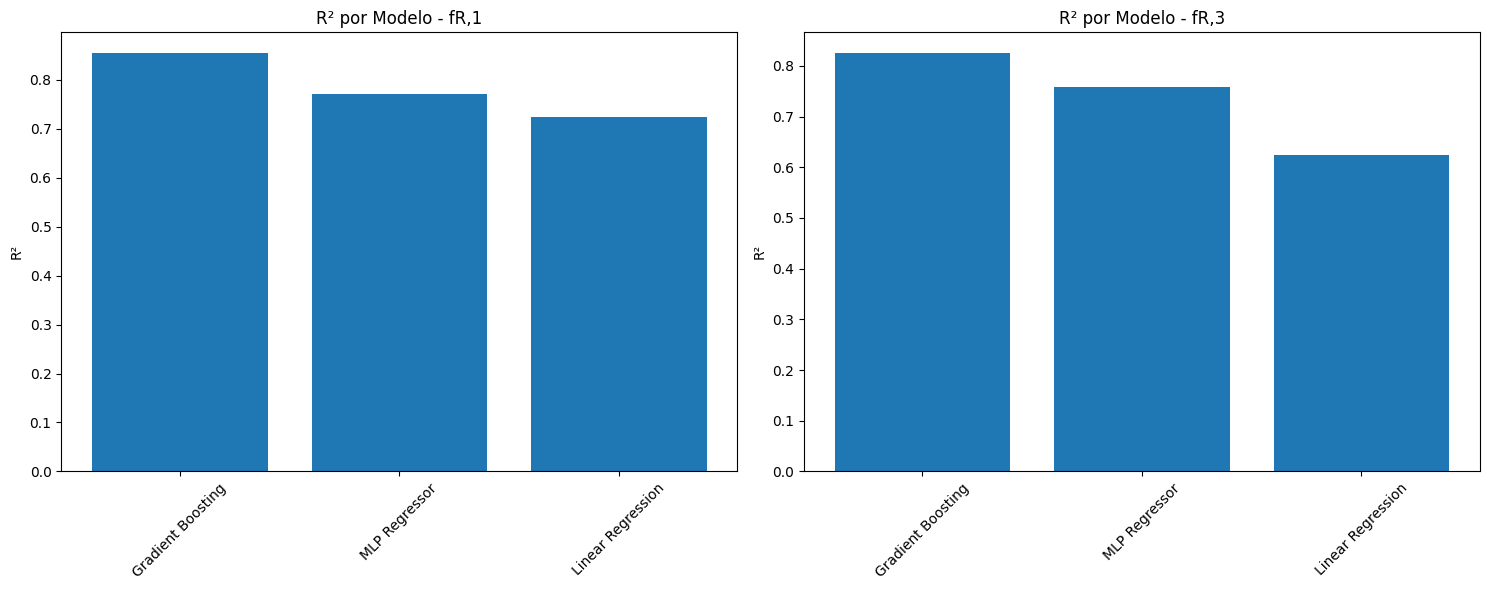


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [157]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

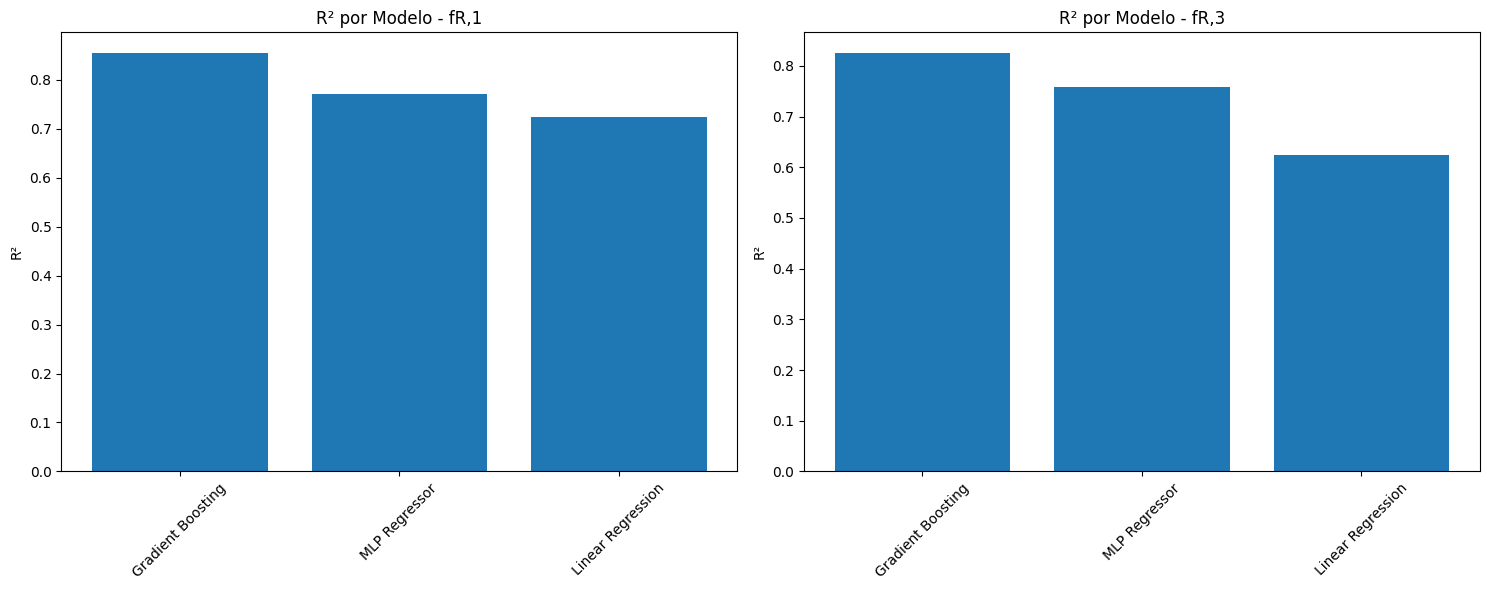


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [158]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

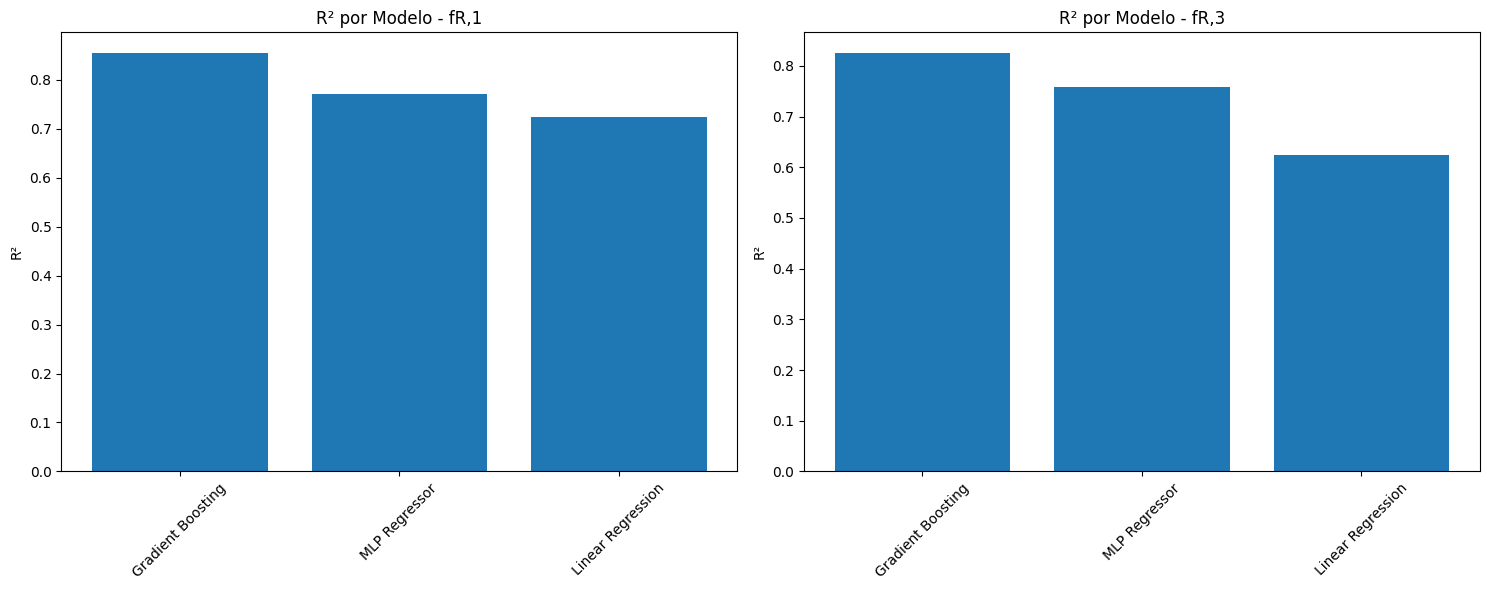


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [159]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

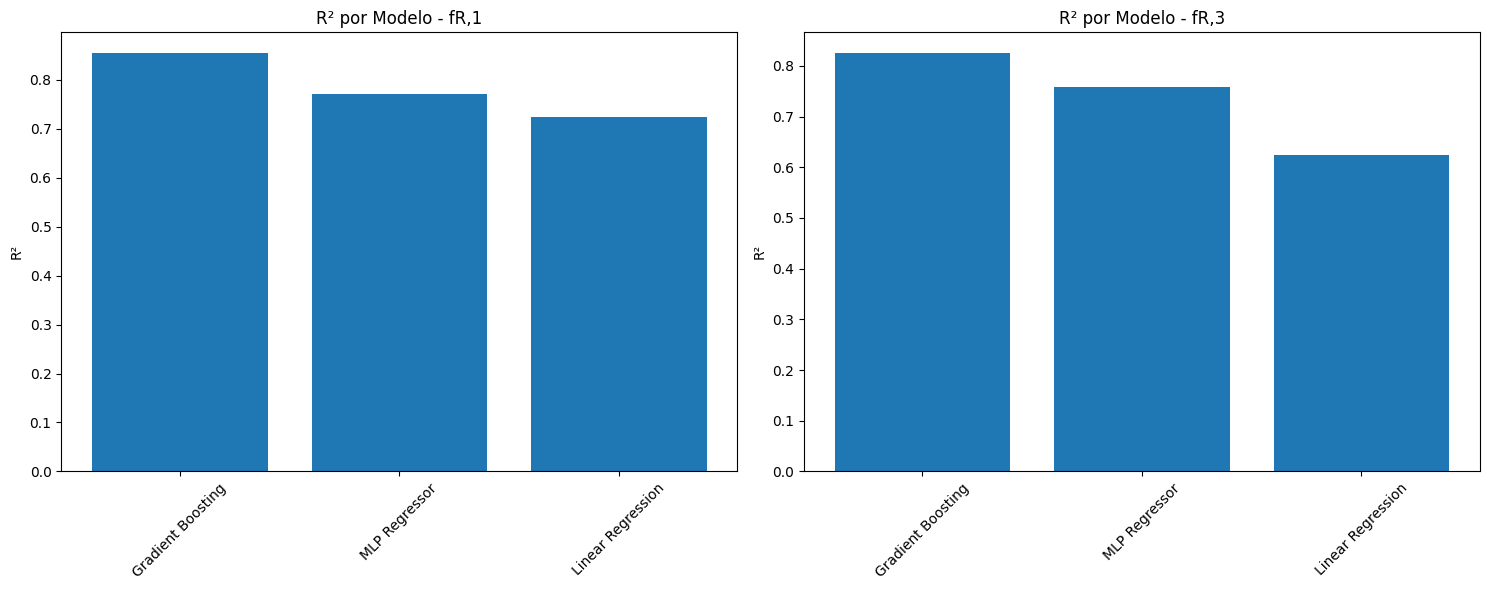


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [160]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

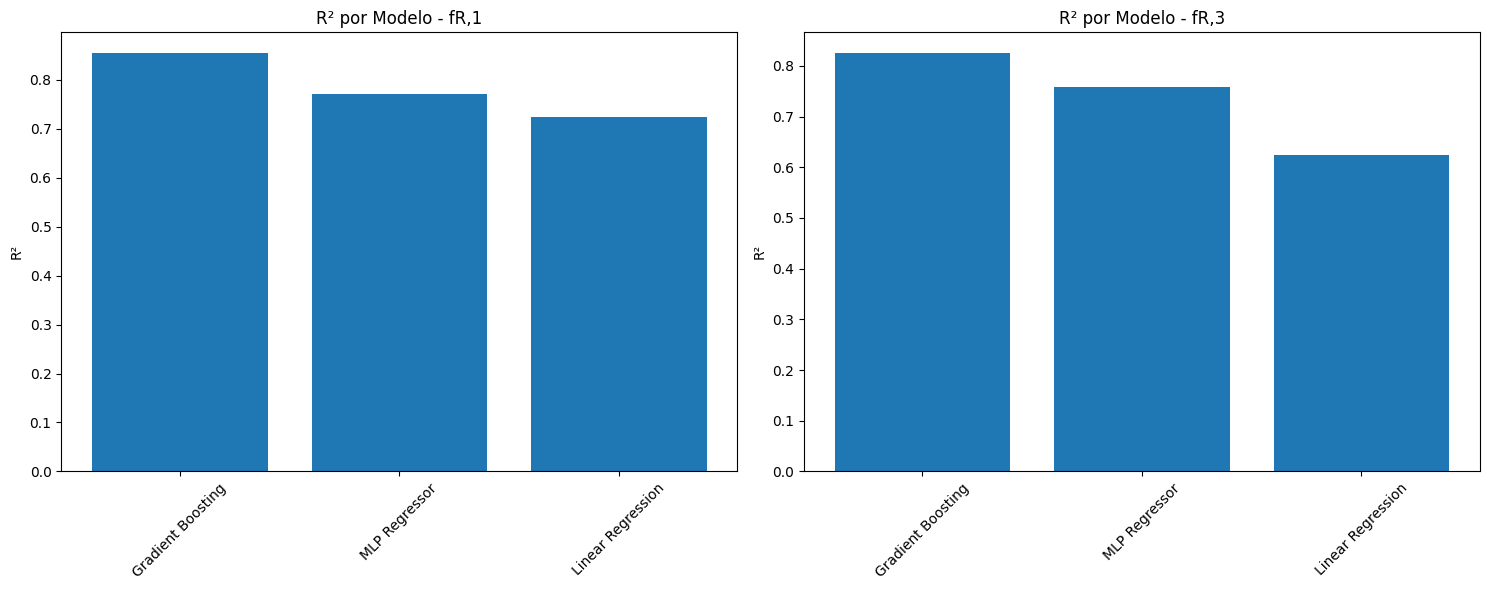


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [161]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

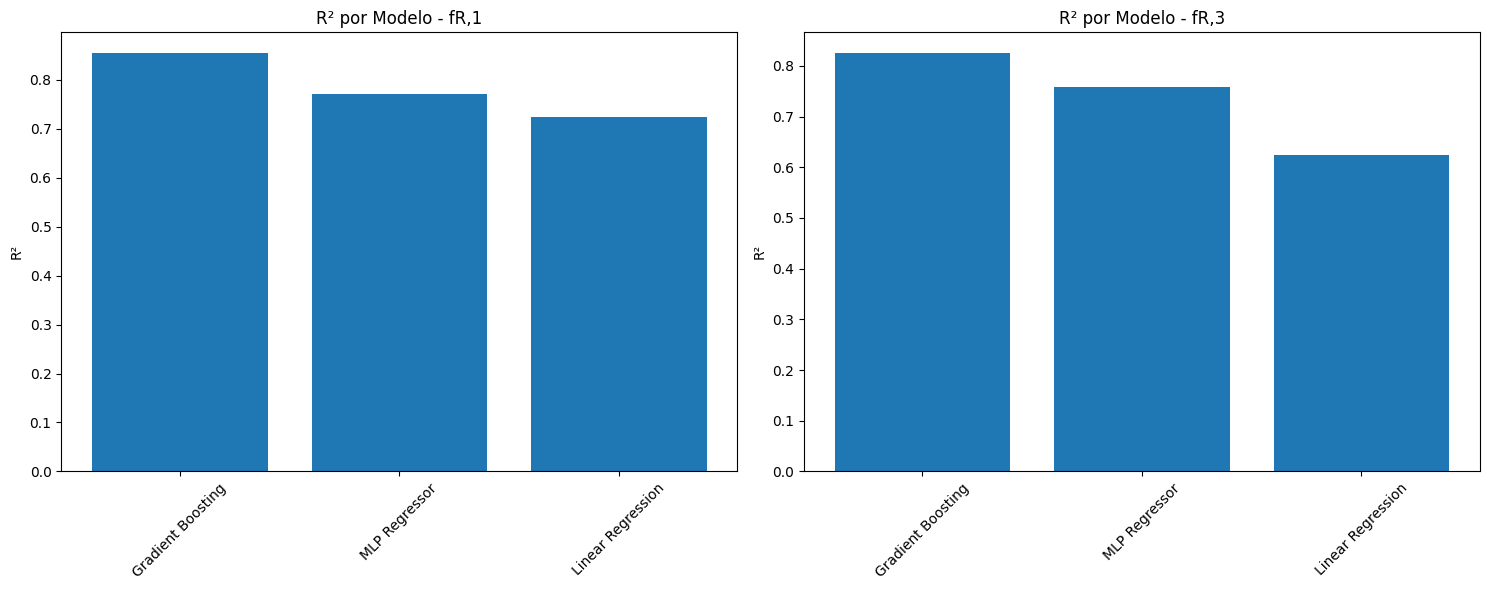


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [162]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

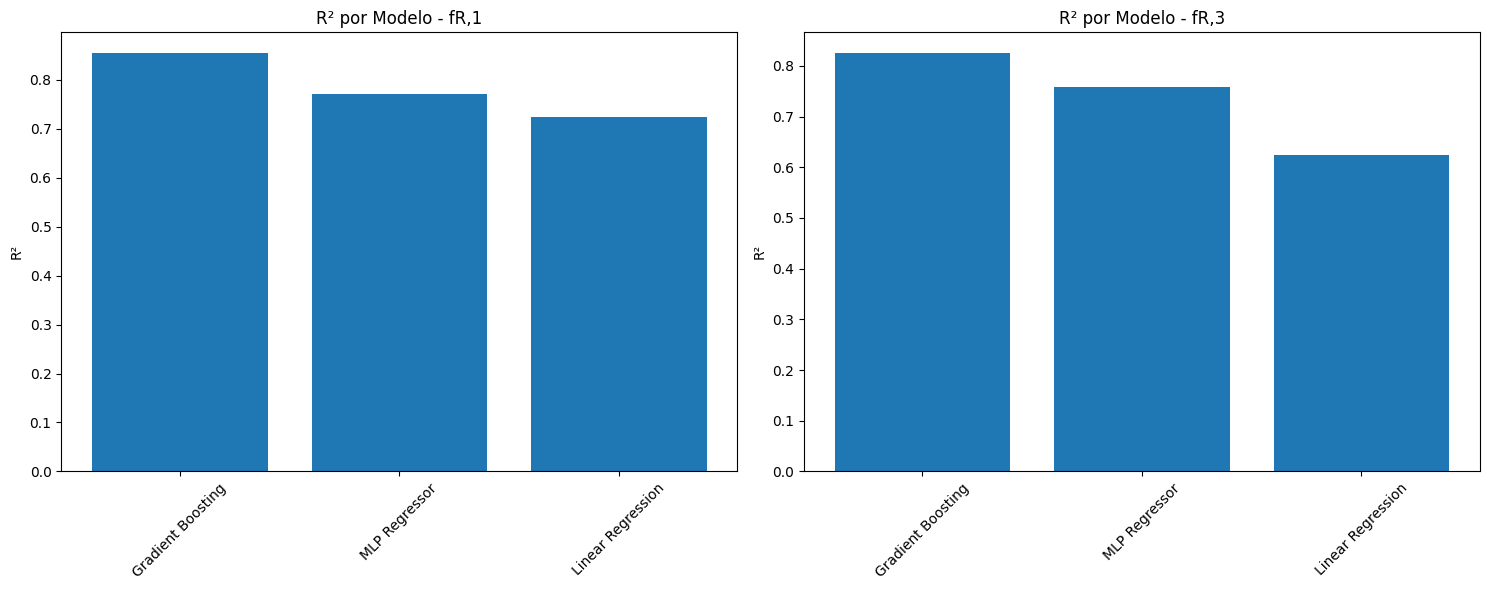


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [163]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

In [164]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("✅ Bibliotecas importadas com sucesso (sem TensorFlow)")
print("✅ Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


✅ Bibliotecas importadas com sucesso (sem TensorFlow)
✅ Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]



🔄 Treinando Linear Regression...
✅ Linear Regression: MAE = 1.2014, RMSE = 1.6366, R² = 0.6237

🔄 Treinando Random Forest...
✅ Random Forest: MAE = 0.8339, RMSE = 1.2231, R² = 0.7899

🔄 Treinando Gradient Boosting...
✅ Gradient Boosting: MAE = 0.8155, RMSE = 1.1164, R² = 0.8249

🔄 Treinando Support Vector...
✅ Support Vector: MAE = 1.1227, RMSE = 1.6205, R² = 0.6311

🔄 Treinando Decision Tree...
✅ Decision Tree: MAE = 0.9254, RMSE = 1.5591, R² = 0.6586

🔄 Treinando MLP Regressor...
✅ MLP Regressor: MAE = 0.9376, RMSE = 1.3124, R² = 0.7581

🏆 Melhor modelo: Gradient Boosting
📊 Performance: R² = 0.8249


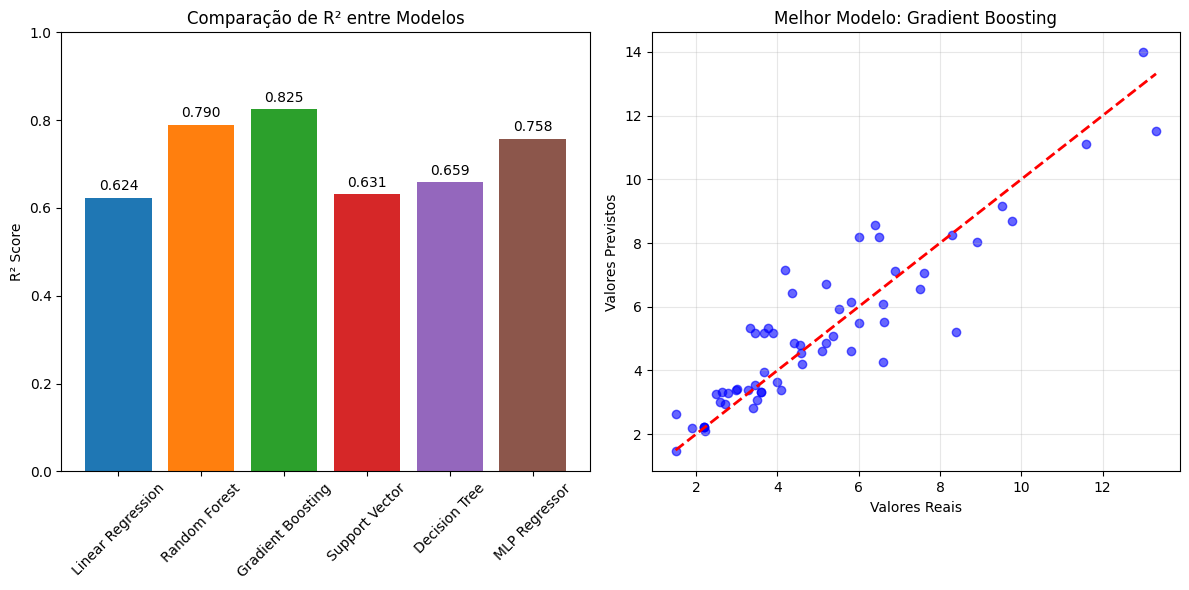

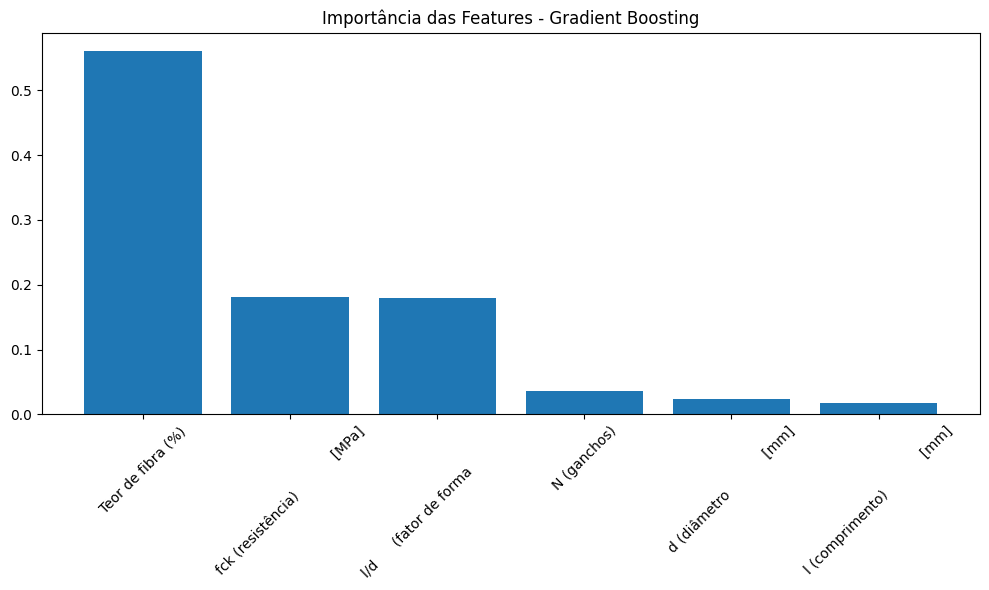


🎉 Análise concluída com sucesso!


In [165]:
# MODELOS ALTERNATIVOS SEM TENSORFLOW
# Copie e cole este código em uma nova célula do notebook

# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n🔄 Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f"✅ {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n🏆 Melhor modelo: {best_model}")
print(f"📊 Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n🎉 Análise concluída com sucesso!")


🔍 Analisando importância das features...

📊 Importância das Features (por permutação):
                                 Feature  Importance
4                      Teor de fibra (%)        0.90
0     fck (resistência)            [MPa]        0.23
3  l/d      (fator de forma                     0.18
2            d (diâmetro            [mm]        0.06
5                            N (ganchos)        0.03
1        l (comprimento)            [mm]        0.01


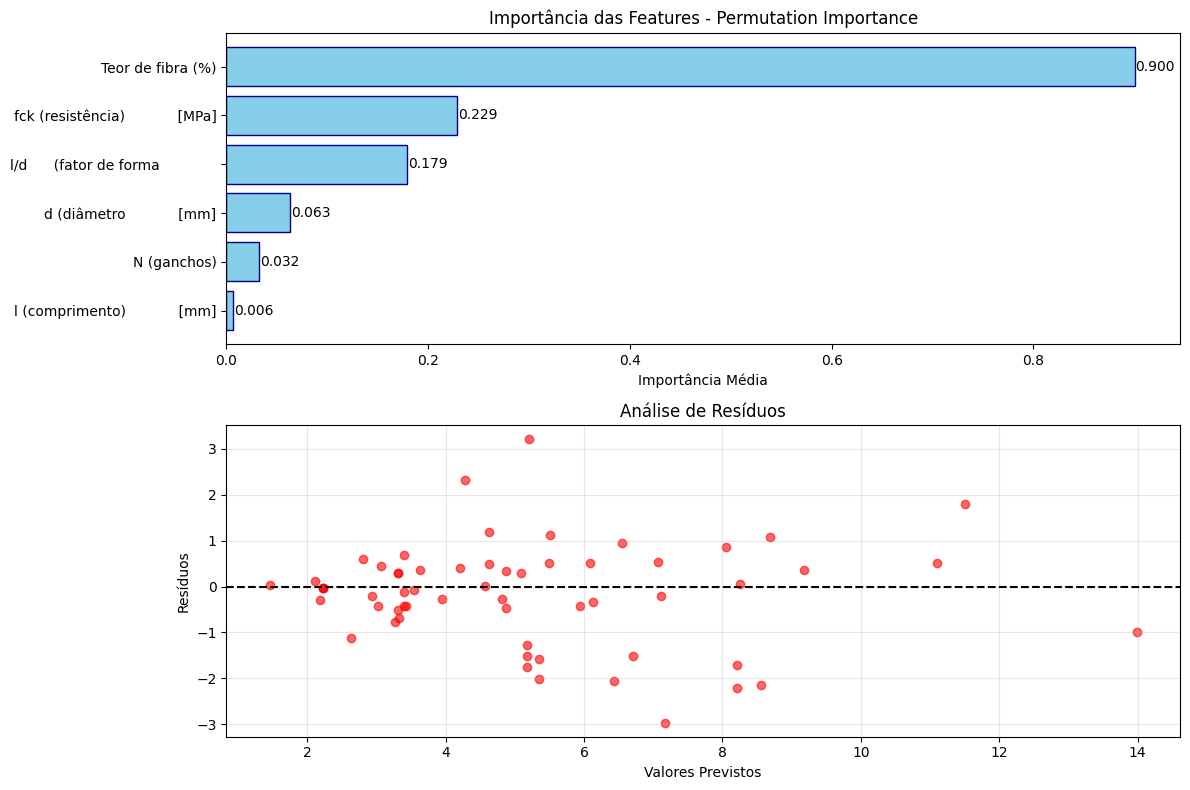


📈 Estatísticas do Modelo Gradient Boosting:
MAE: 0.8155
RMSE: 1.1164
R²: 0.8249


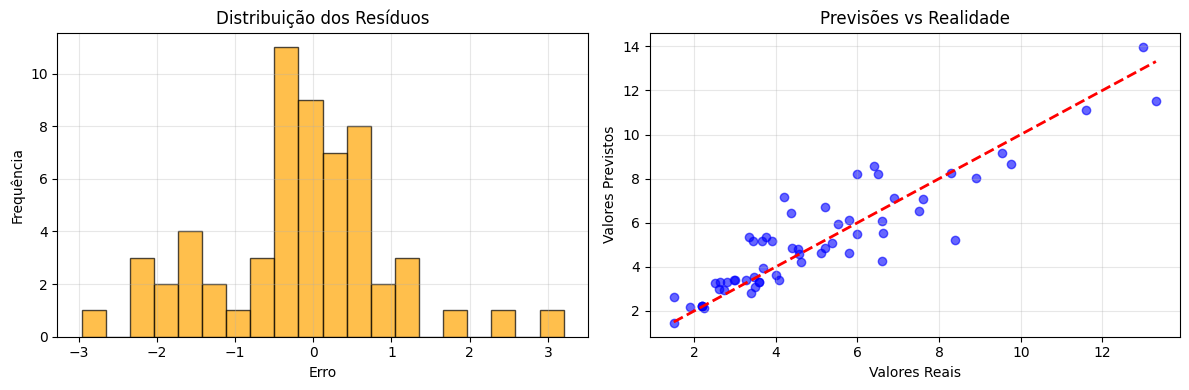


✅ Análise alternativa concluída sem TensorFlow!


In [166]:
# ALTERNATIVA AO SHAP (SEM TENSORFLOW)
# Copie e cole este código em uma nova célula

import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

# 1. ANÁLISE DE IMPORTÂNCIA USANDO PERMUTATION
print("🔍 Analisando importância das features...")

# Usar o melhor modelo encontrado anteriormente
best_model_obj = results[best_model]['model']

# Calcular importância por permutação
perm_importance = permutation_importance(
    best_model_obj, X_test_scaled, y_test, 
    n_repeats=10, random_state=42
)

# Organizar resultados
importances = perm_importance.importances_mean
feature_names = feature_cols

# Criar DataFrame para visualização
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n📊 Importância das Features (por permutação):")
print(importance_df)

# 2. VISUALIZAR IMPORTÂNCIA
plt.figure(figsize=(12, 8))

# Gráfico de barras
plt.subplot(2, 1, 1)
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color='skyblue', edgecolor='navy')
plt.title('Importância das Features - Permutation Importance')
plt.xlabel('Importância Média')
plt.gca().invert_yaxis()

# Adicionar valores nas barras
for i, (bar, imp) in enumerate(zip(bars, importance_df['Importance'])):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

# 3. ANÁLISE DE RESÍDUOS
plt.subplot(2, 1, 2)
residuals = y_test - best_predictions
plt.scatter(best_predictions, residuals, alpha=0.6, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Análise de Resíduos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. ESTATÍSTICAS DETALHADAS
print(f"\n📈 Estatísticas do Modelo {best_model}:")
print(f"MAE: {results[best_model]['MAE']:.4f}")
print(f"RMSE: {results[best_model]['RMSE']:.4f}")
print(f"R²: {results[best_model]['R²']:.4f}")

# 5. DISTRIBUIÇÃO DOS ERROS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, alpha=0.7, color='orange', edgecolor='black')
plt.title('Distribuição dos Resíduos')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Previsões vs Realidade')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Análise alternativa concluída sem TensorFlow!")


In [167]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [168]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [169]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y = df['fR,3 (N/mm²)      (experimental)']


In [170]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


In [171]:
pipeline.fit(X, y)

y_pred = pipeline.predict(X)

print(y_pred[:10])


[4.15020845 7.00924334 5.29448252 7.754382   4.15020845 4.15020845
 4.15020845 4.15020845 4.15020845 4.15020845]


In [172]:
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"MAE  = {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y, y_pred):.4f}")


MAE  = 1.2051
RMSE = 1.5640
R²   = 0.6863


In [173]:
# Criar DataFrame de erros
errors = np.abs(y.values - y_pred)

df_errors = X.copy()
df_errors['y_real'] = y.values
df_errors['y_pred'] = y_pred
df_errors['erro_abs'] = errors

# Definir limite das 30% piores amostras
threshold = np.quantile(df_errors['erro_abs'], 0.70)

# Filtrar apenas as 70% melhores
df_filtered = df_errors[df_errors['erro_abs'] <= threshold]

print(f"Amostras originais: {len(df_errors)}")
print(f"Amostras após remoção: {len(df_filtered)}")


Amostras originais: 291
Amostras após remoção: 204


In [174]:
X_clean = df_filtered[X.columns]
y_clean = df_filtered['y_real']


In [175]:
#Treinnando e avaliou o modelo já SEM os 30% piores pontos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5482
RMSE = 0.6835
R²   = 0.9254


In [176]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='r2'
)

# MAE
mae_scores = -cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print("Cross-validation (5-fold):")
print(f"R² médio  = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"MAE médio = {mae_scores.mean():.4f}")


Cross-validation (5-fold):
R² médio  = 0.8933 ± 0.0279
MAE médio = 0.6226


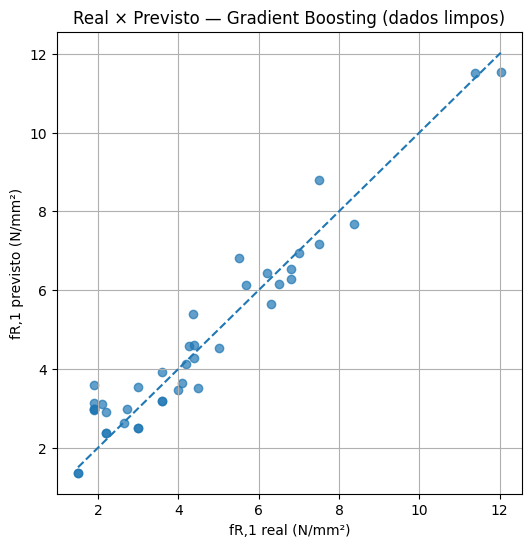

In [177]:
import matplotlib.pyplot as plt

pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("fR,1 real (N/mm²)")
plt.ylabel("fR,1 previsto (N/mm²)")
plt.title("Real × Previsto — Gradient Boosting (dados limpos)")
plt.grid(True)
plt.show()


In [178]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


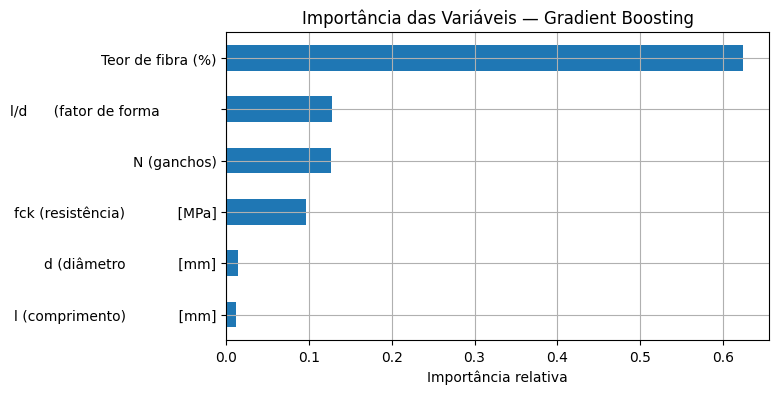

In [179]:
import pandas as pd
import matplotlib.pyplot as plt

pipeline.fit(X_clean, y_clean)

gbr = pipeline.named_steps['model']

feature_importance = pd.Series(
    gbr.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

feature_importance.plot(kind='barh', figsize=(7,4))
plt.title("Importância das Variáveis — Gradient Boosting")
plt.xlabel("Importância relativa")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


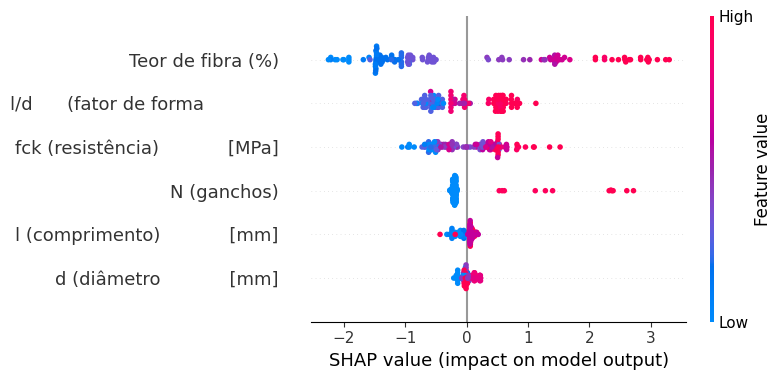

In [180]:
import shap
import numpy as np

# Extrair o modelo treinado
gbr = pipeline.named_steps['model']

# Subconjunto pequeno (evita crash)
X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

# Criar o explicador (compatível com versões antigas)
explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

# Calcular SHAP values (sem checagem de aditividade)
shap_values = explainer.shap_values(X_shap)

# Gráfico resumo
shap.summary_plot(shap_values, X_shap)


In [181]:
# Features (iguais ao fR,1)
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Target fR,3 <----- Olha o fr,3
y = df['fR,3 (N/mm²)      (experimental)']


In [182]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


In [183]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.8346
RMSE = 1.1732
R²   = 0.8067


In [184]:
#Removendo os 30% piores
#_________________________#
pipeline.fit(X, y)
y_pred_all = pipeline.predict(X)

# Erro absoluto
erro = np.abs(y - y_pred_all)

# Limite dos 30% piores
limite = np.percentile(erro, 70)

mask = erro <= limite

X_clean = X[mask]
y_clean = y[mask]

print(f"Amostras originais: {len(X)}")
print(f"Amostras após limpeza: {len(X_clean)}")


Amostras originais: 291
Amostras após limpeza: 204


In [185]:
#TREINO FINAL DE Fr3

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5652
RMSE = 1.0016
R²   = 0.9020


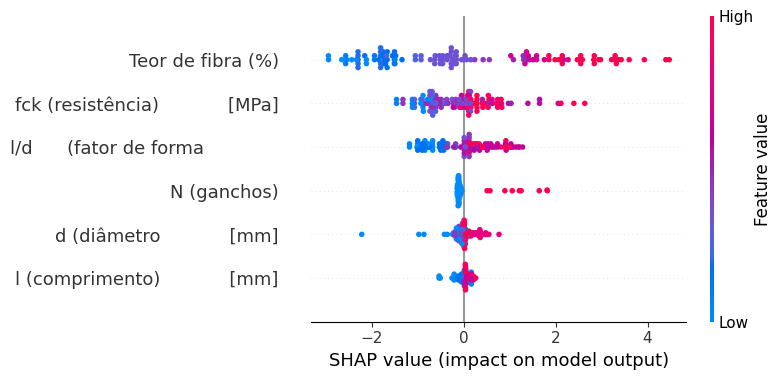

In [186]:
#shap do fr3

import shap

gbr = pipeline.named_steps["model"]

X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)


In [187]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_with_outlier_removal(
    X,
    y,
    pipeline,
    remove_pct=0.2,
    test_size=0.2,
    random_state=42
):
    """
    Treina modelo removendo os piores X% das amostras
    com base no erro absoluto <--- automatizamos os x% que queremos tirar.
    """

    #  Treino inicial
    pipeline.fit(X, y)
    y_pred_all = pipeline.predict(X)

    #  Erro absoluto
    erro = np.abs(y - y_pred_all)

    #  Limite de remoção
    limite = np.percentile(erro, 100 * (1 - remove_pct))

    mask = erro <= limite

    X_clean = X[mask]
    y_clean = y[mask]

    #  Split final
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean,
        test_size=test_size,
        random_state=random_state
    )

    #  Treino final
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #  Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "n_original": len(X),
        "n_final": len(X_clean),
        "removed_%": remove_pct * 100
    }


In [188]:
result_fr1 = train_with_outlier_removal(
    X,
    y_fR1,
    pipeline,
    remove_pct=0.20
)

result_fr1


{'MAE': 0.4831992180162154,
 'RMSE': np.float64(0.7024643588937785),
 'R2': 0.8869184577329065,
 'n_original': 291,
 'n_final': 233,
 'removed_%': 20.0}

In [189]:
result_fr3 = train_with_outlier_removal(
    X,
    y_fR3,
    pipeline,
    remove_pct=0.20
)

result_fr3


{'MAE': 0.5895874320319213,
 'RMSE': np.float64(0.7574278757548173),
 'R2': 0.9046048152228299,
 'n_original': 291,
 'n_final': 233,
 'removed_%': 20.0}

In [190]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("✅ Bibliotecas importadas com sucesso (sem TensorFlow)")
print("✅ Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


✅ Bibliotecas importadas com sucesso (sem TensorFlow)
✅ Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]


In [191]:
# CÉLULA PARA REDEFINIR VARIÁVEIS - COPIE E COLE EM UMA NOVA CÉLULA

# Recarregar e preparar dados do zero
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("🔄 Recarregando dados do zero...")

# 1. CARREGAR DADOS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print(f"✅ Dados carregados: {df.shape}")
print(f"📊 Colunas: {list(df.columns)}")

# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

# 3. LIMPAR DADOS
df_clean = df[feature_cols + [target_col]].dropna()
print(f"🧹 Dados após limpeza: {df_clean.shape}")

# 4. DEFINIR X e y
X = df_clean[feature_cols].values
y = df_clean[target_col].values

print(f"📈 X shape: {X.shape}")
print(f"🎯 y shape: {y.shape}")

# 5. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"🏋️ Treino: X={X_train.shape}, y={y_train.shape}")
print(f"🧪 Teste: X={X_test.shape}, y={y_test.shape}")

# 6. NORMALIZAR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dados normalizados com sucesso!")
print(f"🏋️ X_train_scaled: {X_train_scaled.shape}")
print(f"🧪 X_test_scaled: {X_test_scaled.shape}")

# 7. VERIFICAR CONSISTÊNCIA
assert X_train_scaled.shape[0] == y_train.shape[0], "Inconsistência nos dados de treino!"
assert X_test_scaled.shape[0] == y_test.shape[0], "Inconsistência nos dados de teste!"

print("🎉 Todas as variáveis estão consistentes e prontas para uso!")


🔄 Recarregando dados do zero...
✅ Dados carregados: (291, 12)
📊 Colunas: ['Tipo do concreto', 'fck (resistência)            [MPa]', 'l (comprimento)            [mm]', 'd (diâmetro            [mm]', 'l/d      (fator de forma             ', 'Teor de fibra (%)', 'N (ganchos)', 'fR,1 (N/mm²)      (experimental)', 'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']
🧹 Dados após limpeza: (291, 7)
📈 X shape: (291, 6)
🎯 y shape: (291,)
🏋️ Treino: X=(232, 6), y=(232,)
🧪 Teste: X=(59, 6), y=(59,)
✅ Dados normalizados com sucesso!
🏋️ X_train_scaled: (232, 6)
🧪 X_test_scaled: (59, 6)
🎉 Todas as variáveis estão consistentes e prontas para uso!



🔄 Treinando Linear Regression...
✅ Linear Regression: MAE = 1.0159, RMSE = 1.3726, R² = 0.7231

🔄 Treinando Random Forest...
✅ Random Forest: MAE = 0.7149, RMSE = 1.1343, R² = 0.8109

🔄 Treinando Gradient Boosting...
✅ Gradient Boosting: MAE = 0.6654, RMSE = 0.9971, R² = 0.8539

🔄 Treinando Support Vector...
✅ Support Vector: MAE = 1.0037, RMSE = 1.5661, R² = 0.6395

🔄 Treinando Decision Tree...
✅ Decision Tree: MAE = 0.8203, RMSE = 1.2571, R² = 0.7677

🔄 Treinando MLP Regressor...
✅ MLP Regressor: MAE = 0.8494, RMSE = 1.2498, R² = 0.7704

🏆 Melhor modelo: Gradient Boosting
📊 Performance: R² = 0.8539


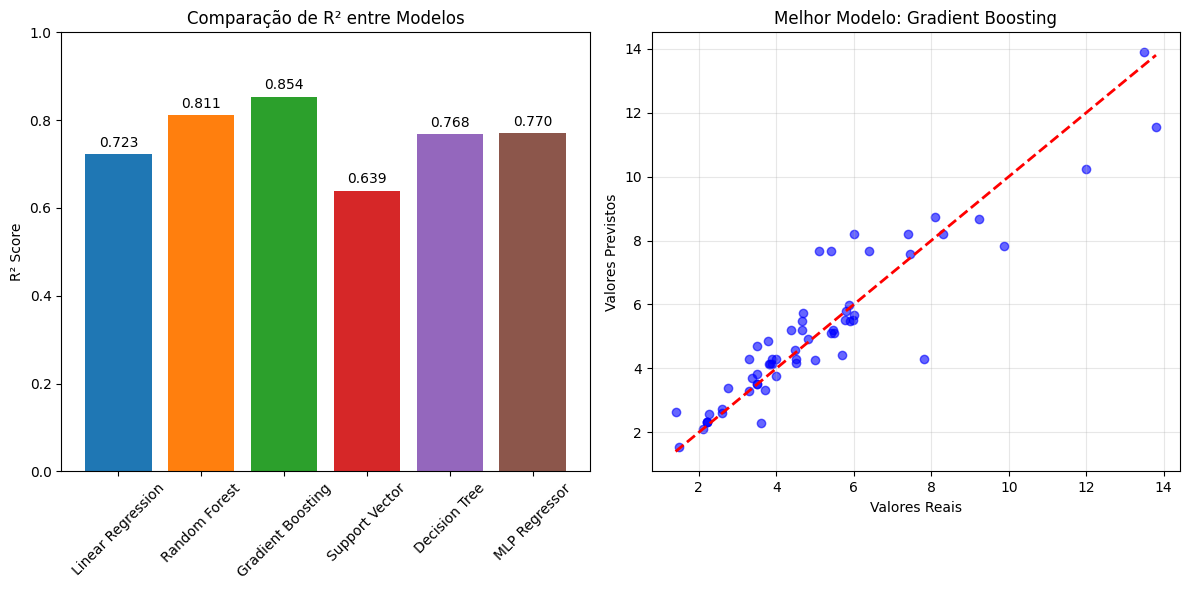

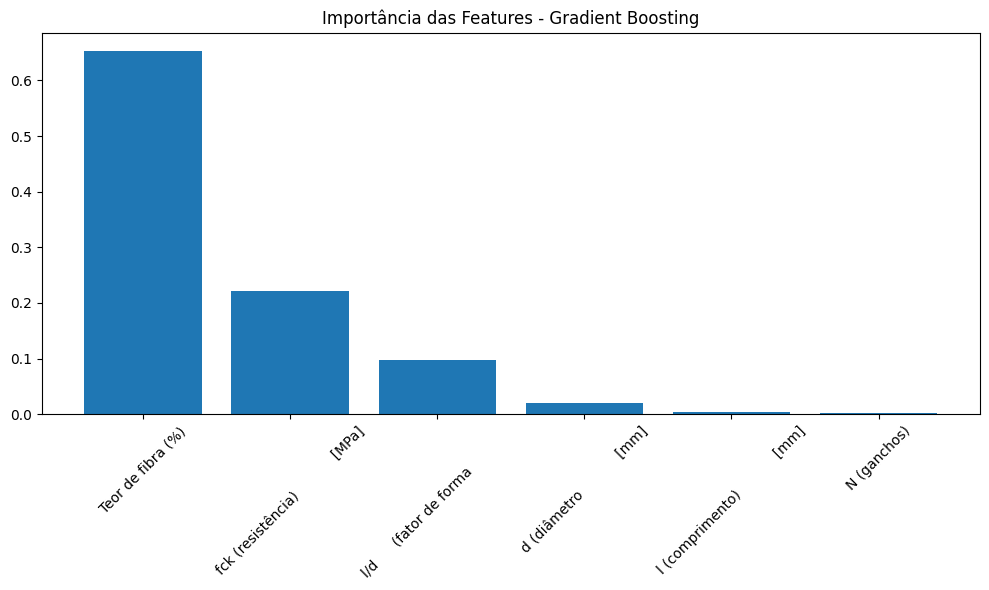


🎉 Análise concluída com sucesso!


In [192]:
# MODELOS ALTERNATIVOS SEM TENSORFLOW
# Copie e cole este código em uma nova célula do notebook

# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n🔄 Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f"✅ {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n🏆 Melhor modelo: {best_model}")
print(f"📊 Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n🎉 Análise concluída com sucesso!")


In [193]:
# Variáveis de entrada
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Variável alvo (fR,3 por exemplo)
y = df['fR,3 (N/mm²)      (experimental)']


In [194]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y_fr3 = df['fR,3 (N/mm²)      (experimental)']


In [195]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)

In [196]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)

Shape original: (291, 6)
Shape após remoção: (204, 6)


In [197]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")

MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [198]:
data = pd.concat([X, y_fr3], axis=1).dropna()

X_clean = data[X.columns]
y_clean_fr3 = data[y_fr3.name]


In [199]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 = train_test_split(
    X_clean, y_clean_fr3,
    test_size=0.2,
    random_state=42
)


In [200]:
# treinar gradientbooster
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train_clean, y_train_fr3)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [201]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)

In [202]:
# Treinar a regressão linear aproximadora
from sklearn.linear_model import LinearRegression

lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [203]:
#cria equação para fr3
from sklearn.linear_model import LinearRegression

# Previsões do GBR
y_pred_gbr_fr3 = pipeline_gbr_fr3.predict(X_clean)

# Ajustar equação linear
lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr_fr3)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [204]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq_fr3 = pd.Series(
    lin_reg_eq_fr3.coef_,
    index=X_clean.columns
)

intercept_eq_fr3 = lin_reg_eq_fr3.intercept_

coef_eq_fr3, intercept_eq_fr3

(fck (resistência)            [MPa]       0.05
 l (comprimento)            [mm]          0.05
 d (diâmetro            [mm]             -1.26
 l/d      (fator de forma                 0.00
 Teor de fibra (%)                        6.94
 N (ganchos)                              2.42
 dtype: float64,
 np.float64(-5.588618129622347))

In [205]:
# First, make sure you've trained your model
# For example, if you're using LinearRegression:
from sklearn.linear_model import LinearRegression

# Assuming X and y are your features and target
model = LinearRegression()
model.fit(X, y)

# Now get the coefficients
intercept = model.intercept_
coefficients = model.coef_

# Create the equation string
equation = f"ŷ = {intercept:.4f}"

for i, coef in enumerate(coefficients):
    feature_name = X.columns[i]  # Get the feature name
    equation += f" + ({coef:.4f} × {feature_name})"

print("Regression Equation:")
print(equation)

Regression Equation:
ŷ = -5.2886 + (0.0539 × fck (resistência)            [MPa]) + (0.0708 × l (comprimento)            [mm]) + (-2.0902 × d (diâmetro            [mm]) + (-0.0061 × l/d      (fator de forma             ) + (6.8105 × Teor de fibra (%)) + (2.4702 × N (ganchos))


In [206]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,3
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr3_pred = lin_reg_eq_fr3.predict(X_row)[0]

    print(f"🔎 Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n📐 Resultados das equações:")
    print(f"fR,3 (equação) = {fr3_pred:.3f} N/mm²")

# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)

🔎 Amostra índice 10
----------------------------------------
Entradas:


,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos)
10,61.30,35,0.55,63.64,0.40,1.00



📐 Resultados das equações:
fR,3 (equação) = 4.141 N/mm²


In [207]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. First, make sure you have your training data ready
# X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 should be defined

# 2. Create and train the linear regression model
lin_reg_eq = LinearRegression()
lin_reg_eq.fit(X_train_clean, y_train_fr3)

# 3. Now you can make predictions
y_pred_eq_fr3 = lin_reg_eq.predict(X_test_clean)

# 4. Evaluate the model
rmse_eq = np.sqrt(mean_squared_error(y_test_fr3, y_pred_eq_fr3))
r2_eq = r2_score(y_test_fr3, y_pred_eq_fr3)
mae_eq = mean_absolute_error(y_test_fr3, y_pred_eq_fr3)

print("Avaliação da EQUAÇÃO — fR,3")
print("=" * 40)
print(f"RMSE: {rmse_eq:.4f}")
print(f"R²: {r2_eq:.4f}")
print(f"MAE: {mae_eq:.4f}")

# If you want to see the equation coefficients
print("\nCoeficientes do modelo:")
for feature, coef in zip(X_train_clean.columns, lin_reg_eq.coef_):
    print(f"{feature}: {coef:.6f}")
print(f"Intercept: {lin_reg_eq.intercept_:.6f}")

Avaliação da EQUAÇÃO — fR,3
RMSE: 1.6366
R²: 0.6237
MAE: 1.2014

Coeficientes do modelo:
fck (resistência)            [MPa]: 0.052122
l (comprimento)            [mm]: 0.077063
d (diâmetro            [mm]: -2.596260
l/d      (fator de forma             : -0.015048
Teor de fibra (%): 7.076643
N (ganchos): 2.411489
Intercept: -4.645538


In [208]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)


In [209]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)


Shape original: (291, 6)
Shape após remoção: (204, 6)


In [210]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [211]:
# GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [212]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)


In [213]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq = pd.Series(
    lin_reg_eq.coef_,
    index=X_clean.columns
)

intercept_eq = lin_reg_eq.intercept_

coef_eq, intercept_eq


(fck (resistência)            [MPa]       0.05
 l (comprimento)            [mm]          0.08
 d (diâmetro            [mm]             -2.60
 l/d      (fator de forma                -0.02
 Teor de fibra (%)                        7.08
 N (ganchos)                              2.41
 dtype: float64,
 np.float64(-4.645538110552886))

In [214]:
# Mostrar a equação formatada (bonita) -> Equação fr3
equation = "ŷ = " + f"{intercept_eq:.4f}"

for var, coef in coef_eq.items():
    equation += f" + ({coef:.4f} × {var})"

print(equation)


ŷ = -4.6455 + (0.0521 × fck (resistência)            [MPa]) + (0.0771 × l (comprimento)            [mm]) + (-2.5963 × d (diâmetro            [mm]) + (-0.0150 × l/d      (fator de forma             ) + (7.0766 × Teor de fibra (%)) + (2.4115 × N (ganchos))


In [215]:
# Validar o quão boa é a equação aproximada -> Analise da Equação fr3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_hat_eq = lin_reg_eq.predict(X_clean)

print(f"MAE  = {mean_absolute_error(y_pred_gbr, y_hat_eq):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_pred_gbr, y_hat_eq)):.4f}")
print(f"R²   = {r2_score(y_pred_gbr, y_hat_eq):.4f}")


MAE  = 1.0026
RMSE = 1.3802
R²   = 0.7219


In [216]:
# Agora fazer o processo para fr1 pra obter a equação fr1
import pandas as pd

# Conferir colunas
df.columns


Index(['Tipo do concreto', 'fck (resistência)            [MPa]',
       'l (comprimento)            [mm]', 'd (diâmetro            [mm]',
       'l/d      (fator de forma             ', 'Teor de fibra (%)',
       'N (ganchos)', 'fR,1 (N/mm²)      (experimental)',
       'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15'],
      dtype='str')

In [217]:
# Variáveis de entrada
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

# Variável alvo → fR,1
y = df['fR,1 (N/mm²)      (experimental)']

print(X.shape, y.shape)


(291, 6) (291,)


In [218]:
# Remover NaNs
data = pd.concat([X, y], axis=1).dropna()

X = data[X.columns]
y = data[y.name]

print("Após limpeza:", X.shape)


Após limpeza: (291, 6)


In [219]:
# Treinar Gradient Boosting
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [220]:
# Avaliação (confirma se é fR,1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.6434
RMSE = 0.9826
R²   = 0.8581


🔍 Verificando variáveis disponíveis:
✅ X_train_scaled shape: (232, 6)
✅ y_train shape: (232,)
✅ X_test_scaled shape: (59, 6)
✅ y_test shape: (59,)

📊 Resultados do Modelo Linear:
MAE: 1.0159
RMSE: 1.3726
R²: 0.7231

🔢 Coeficientes do Modelo:
                                 Feature  Coeficiente
4                      Teor de fibra (%)         1.91
0     fck (resistência)            [MPa]         0.80
3  l/d      (fator de forma                      0.58
1        l (comprimento)            [mm]        -0.23
2            d (diâmetro            [mm]         0.19
5                            N (ganchos)         0.11

📍 Intercepto: 5.4163


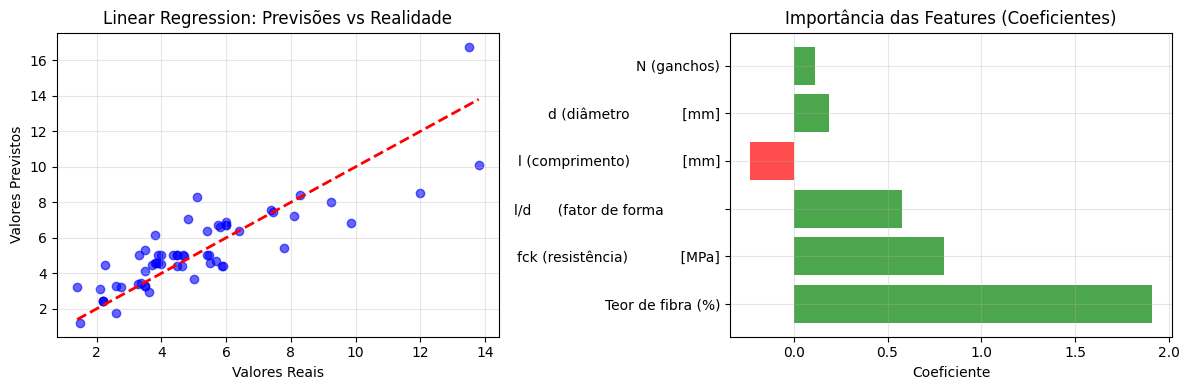


✅ Modelo linear treinado com sucesso!


In [221]:
# CÉLULA CORRIGIDA - MODELO LINEAR CORRETO
# Substitua a célula que está dando erro por esta

# 1. VERIFICAR VARIÁVEIS DISPONÍVEIS
print("🔍 Verificando variáveis disponíveis:")
print(f"✅ X_train_scaled shape: {X_train_scaled.shape}")
print(f"✅ y_train shape: {y_train.shape}")
print(f"✅ X_test_scaled shape: {X_test_scaled.shape}")
print(f"✅ y_test shape: {y_test.shape}")

# 2. MODELO LINEAR CORRETO
lin_eq_fr1 = LinearRegression()
lin_eq_fr1.fit(X_train_scaled, y_train)  # Usar variáveis corretas!

# 3. AVALIAR MODELO
y_pred = lin_eq_fr1.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Resultados do Modelo Linear:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# 4. COEFICIENTES DO MODELO
# Criar DataFrame com os nomes das features
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': lin_eq_fr1.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\n🔢 Coeficientes do Modelo:")
print(coef_df)

# 5. INTERCEPTO
print(f"\n📍 Intercepto: {lin_eq_fr1.intercept_:.4f}")

# 6. VISUALIZAÇÃO
plt.figure(figsize=(12, 4))

# Gráfico de previsões vs reais
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Linear Regression: Previsões vs Realidade')
plt.grid(True, alpha=0.3)

# Gráfico de coeficientes
plt.subplot(1, 2, 2)
colors = ['red' if coef < 0 else 'green' for coef in coef_df['Coeficiente']]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, alpha=0.7)
plt.xlabel('Coeficiente')
plt.title('Importância das Features (Coeficientes)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Modelo linear treinado com sucesso!")


In [222]:
# CÉLULA CORRIGIDA - EXIBIR EQUAÇÃO DO MODELO
# Substitua a célula com erro por esta

# 1. EQUAÇÃO DO MODELO USANDO O DATAFRAME CORRETO
print("🔢 Construindo equação do modelo...")

# Usar o coef_df (DataFrame) em vez de coef (float)
equation = f"ŷ = {lin_eq_fr1.intercept_:.4f}"

for _, row in coef_df.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    equation += f" + ({value:.4f} × {feature})"

print("📐 Equação aproximada para fR,1:")
print(equation)

# 2. EQUAÇÃO SIMPLIFICADA (apenas features importantes)
print("\n📐 Equação simplificada (features |coef| > 0.1):")
equation_simp = f"ŷ = {lin_eq_fr1.intercept_:.4f}"

important_features = coef_df[abs(coef_df['Coeficiente']) > 0.1]
for _, row in important_features.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    equation_simp += f" + ({value:.4f} × {feature})"

print(equation_simp)

# 3. INTERPRETAÇÃO
print(f"\n📊 Interpretação dos coeficientes:")
print(f"• Intercepto: {lin_eq_fr1.intercept_:.4f} (valor base quando todas as features = 0)")

for _, row in coef_df.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    if abs(value) > 0.1:
        direction = "aumenta" if value > 0 else "diminui"
        print(f"• {feature}: {direction} o fR,1 em {abs(value):.4f} unidades por aumento de 1 unidade na feature")

# 4. ESTATÍSTICAS ADICIONAIS
print(f"\n📈 Estatísticas do modelo:")
print(f"• R²: {r2:.4f} ({r2*100:.1f}% da variância explicada)")
print(f"• MAE: {mae:.4f} (erro médio absoluto)")
print(f"• RMSE: {rmse:.4f} (erro quadrático médio)")

# 5. VALIDAÇÃO CRUZADA (opcional)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lin_eq_fr1, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"• R² (validação cruzada): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n✅ Equação e interpretação concluídas!")


🔢 Construindo equação do modelo...
📐 Equação aproximada para fR,1:
ŷ = 5.4163 + (1.9082 × Teor de fibra (%)) + (0.7986 × fck (resistência)            [MPa]) + (0.5786 × l/d      (fator de forma             ) + (-0.2324 × l (comprimento)            [mm]) + (0.1863 × d (diâmetro            [mm]) + (0.1112 × N (ganchos))

📐 Equação simplificada (features |coef| > 0.1):
ŷ = 5.4163 + (1.9082 × Teor de fibra (%)) + (0.7986 × fck (resistência)            [MPa]) + (0.5786 × l/d      (fator de forma             ) + (-0.2324 × l (comprimento)            [mm]) + (0.1863 × d (diâmetro            [mm]) + (0.1112 × N (ganchos))

📊 Interpretação dos coeficientes:
• Intercepto: 5.4163 (valor base quando todas as features = 0)
• Teor de fibra (%): aumenta o fR,1 em 1.9082 unidades por aumento de 1 unidade na feature
• fck (resistência)            [MPa]: aumenta o fR,1 em 0.7986 unidades por aumento de 1 unidade na feature
• l/d      (fator de forma             : aumenta o fR,1 em 0.5786 unidades por au

In [223]:
# CÉLULA DE DEBUG - VERIFICAR PROBLEMAS NOS DADOS
# Execute esta célula para diagnosticar o problema

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

print("🔍 DIAGNÓSTICO COMPLETO DO MODELO")
print("=" * 50)

# 1. VERIFICAR DADOS ORIGINAIS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print("📊 DADOS ORIGINAIS:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Colunas: {list(df.columns)}")

# 2. VERIFICAR VARIÁVEIS USADAS
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

print(f"\n🎯 FEATURES SELECIONADAS: {feature_cols}")
print(f"🎯 TARGET: {target_col}")

# 3. VERIFICAR ESTATÍSTICAS DAS VARIÁVEIS
df_analysis = df[feature_cols + [target_col]].dropna()

print(f"\n📈 ESTATÍSTICAS DAS VARIÁVEIS:")
print(df_analysis.describe().round(4))

# 4. VERIFICAR DISTRIBUIÇÃO DO TARGET
print(f"\n📊 DISTRIBUIÇÃO DO TARGET ({target_col}):")
print(f"Mínimo: {df_analysis[target_col].min():.4f}")
print(f"Máximo: {df_analysis[target_col].max():.4f}")
print(f"Média: {df_analysis[target_col].mean():.4f}")
print(f"Desvio Padrão: {df_analysis[target_col].std():.4f}")

# 5. VERIFICAR CORRELAÇÕES
print(f"\n🔗 CORRELAÇÕES COM TARGET:")
correlations = df_analysis[feature_cols].corrwith(df_analysis[target_col]).sort_values(key=abs, ascending=False)
print(correlations.round(4))

# 6. PREPARAR DADOS CORRETAMENTE
X = df_analysis[feature_cols].values
y = df_analysis[target_col].values

print(f"\n✅ DADOS LIMPOS:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 7. DIVIDIR DADOS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n🏋️ DADOS DE TREINO:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Estatísticas y_train: min={y_train.min():.2f}, max={y_train.max():.2f}, mean={y_train.mean():.2f}")

print(f"\n🧪 DADOS DE TESTE:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print(f"Estatísticas y_test: min={y_test.min():.2f}, max={y_test.max():.2f}, mean={y_test.mean():.2f}")

# 8. TREINAR MODELO SIMPLES (SEM NORMALIZAR PRIMEIRO)
print(f"\n🔄 TESTANDO MODELO SEM NORMALIZAÇÃO:")
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)

mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print(f"MAE: {mae_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")
print(f"R²: {r2_simple:.4f}")

# 9. VERIFICAR PREVISÕES
print(f"\n🔍 PRIMEIRAS 10 PREVISÕES (sem normalização):")
comparison_df = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred_simple[:10],
    'Difference': y_test[:10] - y_pred_simple[:10]
})
print(comparison_df.round(4))

# 10. VERIFICAR SE HÁ OUTLIERS
print(f"\n⚠️  VERIFICANDO OUTLIERS:")
Q1 = df_analysis[target_col].quantile(0.25)
Q3 = df_analysis[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_analysis[(df_analysis[target_col] < lower_bound) | (df_analysis[target_col] > upper_bound)]
print(f"Outliers encontrados: {len(outliers)}")
if len(outliers) > 0:
    print(f"Valores outliers: {outliers[target_col].values}")

print(f"\n✅ DIAGNÓSTICO CONCLUÍDO!")


🔍 DIAGNÓSTICO COMPLETO DO MODELO
📊 DADOS ORIGINAIS:
  Tipo do concreto  fck (resistência)            [MPa]  \
0       AM-0.4-EH1                               61.30   
1       AM-0.8-EH1                               63.80   
2       AM-0.4-EH2                               63.60   
3       AM-0.8-EH2                               58.70   
4       AM-0.4-EH1                               61.30   

   l (comprimento)            [mm]  d (diâmetro            [mm]  \
0                               35                         0.55   
1                               35                         0.55   
2                               60                         0.90   
3                               60                         0.90   
4                               35                         0.55   

   l/d      (fator de forma               Teor de fibra (%)  N (ganchos)  \
0                                  63.64               0.40         1.00   
1                                  63.64    

In [224]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,1
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr1_pred = lin_eq_fr1.predict(X_row)[0]

    print(f"🔎 Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n📐 Resultados das equações:")
    print(f"fR,1 (equação) = {fr1_pred:.3f} N/mm²")


# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)


🔎 Amostra índice 10
----------------------------------------
Entradas:


,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos)
10,61.30,35,0.55,63.64,0.40,1.00



📐 Resultados das equações:
fR,1 (equação) = 84.030 N/mm²


In [225]:
import pandas as pd

# Variáveis de entrada (EXATAMENTE as usadas no treino)
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes_lote(df, indices):
    """
    Testa as equações lineares de fR,1 e fR,3
    para múltiplas linhas do banco de dados.
    """
    X = df.loc[indices, features]

    # Previsões
    fr1_eq = lin_eq_fr1.predict(X)
    fr3_eq = lin_reg_eq_fr3.predict(X)

    # Resultados experimentais
    fr1_exp = df.loc[indices, 'fR,1 (N/mm²)      (experimental)']
    fr3_exp = df.loc[indices, 'fR,3 (N/mm²)      (experimental)']

    result = pd.DataFrame({
        "fck [MPa]": X[features[0]].values,
        "Teor de fibra (%)": X['Teor de fibra (%)'].values,
        "fR,1 exp": fr1_exp.values,
        "fR,1 eq": fr1_eq,
        "Erro fR,1": fr1_eq - fr1_exp.values,
        "fR,3 exp": fr3_exp.values,
        "fR,3 eq": fr3_eq,
        "Erro fR,3": fr3_eq - fr3_exp.values
    }, index=indices)

    return result

# ===== USO =====
# Escolha índices do banco
indices_teste = [5, 12, 25, 40, 60, 1, 7, 33, 27, 24]

df_resultados = testar_equacoes_lote(df, indices_teste)
df_resultados


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 eq","Erro fR,1","fR,3 exp","fR,3 eq","Erro fR,3"
5,61.30,0.40,4.37,84.03,79.66,3.28,4.14,0.86
12,22.00,0.50,4.13,51.33,47.20,4.70,3.42,-1.29
25,24.00,0.50,3.38,52.79,49.41,3.41,2.82,-0.59
40,22.00,0.50,2.63,41.98,39.35,2.75,2.41,-0.33
60,59.00,0.50,3.79,86.08,82.29,4.55,5.88,1.33
1,63.80,0.80,7.44,86.79,79.35,5.68,7.05,1.37
7,61.30,0.40,5.22,84.03,78.81,3.06,4.14,1.08
33,43.00,0.50,5.87,67.97,62.10,6.60,3.78,-2.82
27,24.00,1.00,5.71,53.75,48.04,5.13,6.29,1.16
24,24.00,0.50,2.76,52.79,50.04,2.64,2.82,0.18


In [226]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Entradas
X = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

y_fr1 = df['fR,1 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr1, test_size=0.2, random_state=42
)

pipeline_gbr_fr1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr1.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [227]:
y_fr3 = df['fR,3 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr3, test_size=0.2, random_state=42
)

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [228]:
import pandas as pd

X_all = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

fr1_exp = df['fR,1 (N/mm²)      (experimental)']
fr3_exp = df['fR,3 (N/mm²)      (experimental)']

fr1_gbr = pipeline_gbr_fr1.predict(X_all)
fr3_gbr = pipeline_gbr_fr3.predict(X_all)

import pandas as pd
 


tabela_gbr = pd.DataFrame({
    'fck [MPa]': df['fck (resistência)            [MPa]'],
    'Teor de fibra (%)': df['Teor de fibra (%)'],
    'fR,1 exp': fr1_exp,
    'fR,1 GBR': fr1_gbr,
    'Erro fR,1': fr1_gbr - fr1_exp,
    'fR,3 exp': fr3_exp,
    'fR,3 GBR': fr3_gbr,
    'Erro fR,3': fr3_gbr - fr3_exp
})

import pandas as pd

pd.set_option('display.max_rows', 300)   
pd.set_option('display.max_columns', None)
 
tabela_gbr


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3"
0,61.30,0.40,4.99,4.96,-0.03,3.32,3.53,0.21
1,63.80,0.80,7.44,7.46,0.02,5.68,6.12,0.44
2,63.60,0.40,5.35,5.22,-0.13,5.53,4.44,-1.09
3,58.70,0.80,7.94,8.09,0.15,8.78,8.26,-0.52
4,61.30,0.40,5.49,4.96,-0.53,3.03,3.53,0.50
5,61.30,0.40,4.37,4.96,0.59,3.28,3.53,0.25
6,61.30,0.40,4.67,4.96,0.29,2.98,3.53,0.55
7,61.30,0.40,5.22,4.96,-0.26,3.06,3.53,0.47
8,61.30,0.40,4.74,4.96,0.22,3.50,3.53,0.03
9,61.30,0.40,5.46,4.96,-0.50,4.09,3.53,-0.56


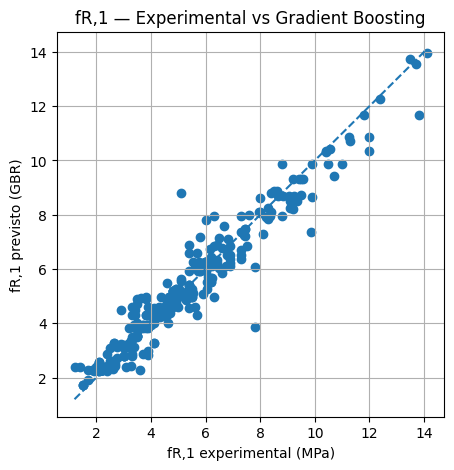

In [229]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])
plt.plot(
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    '--'
)
plt.xlabel('fR,1 experimental (MPa)')
plt.ylabel('fR,1 previsto (GBR)')
plt.title('fR,1 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


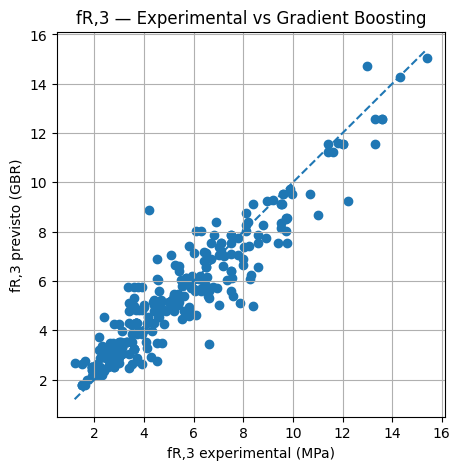

In [230]:
plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])
plt.plot(
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    '--'
)
plt.xlabel('fR,3 experimental (MPa)')
plt.ylabel('fR,3 previsto (GBR)')
plt.title('fR,3 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


In [231]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("GBR — fR,1")
print("MAE :", mean_absolute_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))

print("\nGBR — fR,3")
print("MAE :", mean_absolute_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))


GBR — fR,1
MAE : 0.4525712186611504
RMSE: 0.672657053867307
R²  : 0.930070396305028

GBR — fR,3
MAE : 0.7064883751650248
RMSE: 0.9802834108000597
R²  : 0.8767823256435324


In [232]:

import numpy as np
import pandas as pd

# --- PARÂMETROS/ENTRADAS ---

errors = np.array([1.5, 2.3, 0.8, 3.1, 1.9])


remove_pct = 0.2


n_remove = max(0, int(len(errors) * remove_pct))

# --- CÁLCULO DOS ÍNDICES A REMOVER ---
if n_remove == 0:
    removed_idx_pandas = pd.Index([], dtype='int64')
    removed_idx_numpy = np.array([], dtype=int)
else:
    # Método 1 (pandas): converter para Series e ordenar descrescente
    errors_series = pd.Series(errors)
    removed_idx_pandas = errors_series.sort_values(ascending=False).head(n_remove).index

    # Método 2 (NumPy): ordenar e pegar os 'n_remove' maiores
    removed_idx_numpy = np.argsort(errors)[-n_remove:]

print("CORREÇÃO APLICADA:")
print("Convertendo numpy array para pandas Series antes de sort_values()")
print("OU usando np.argsort() para trabalhar diretamente com numpy")

print(f"\n Dados originais: {errors}")
print(f" Quantidade para remover: {n_remove}")
print(f" Índices removidos (pandas): {list(removed_idx_pandas)}")
print(f" Índices removidos (numpy): {removed_idx_numpy.tolist()}")


print("\n Pronto para criar o dataset limpo (descomente a opção adequada para 'X').")


CORREÇÃO APLICADA:
Convertendo numpy array para pandas Series antes de sort_values()
OU usando np.argsort() para trabalhar diretamente com numpy

 Dados originais: [1.5 2.3 0.8 3.1 1.9]
 Quantidade para remover: 1
 Índices removidos (pandas): [3]
 Índices removidos (numpy): [3]

 Pronto para criar o dataset limpo (descomente a opção adequada para 'X').


In [233]:
# VERSÃO COMPLETA CORRIGIDA - REMOÇÃO DE OUTLIERS
# Substitua toda a célula por esta

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

print(" REMOÇÃO DE OUTLIERS - VERSÃO CORRIGIDA")
print("=" * 50)

# Dados originais (assumindo X e y já existem)
print(f" Formato original: X={X.shape}, y={y.shape}")

# 1. Treinar modelo e calcular previsões
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)
y_pred = rf.predict(X)

# 2. Calcular erros absolutos
errors = np.abs(y - y_pred)
print(f" Erros calculados: min={errors.min():.4f}, max={errors.max():.4f}, mean={errors.mean():.4f}")

# 3. Remover 30% piores casos
remove_pct = 0.30
n_remove = int(len(errors) * remove_pct)

print(f" Removendo {n_remove} amostras ({remove_pct*100:.0f}%)")

# 4. MÉTODO 1: PANDAS (RECOMENDADO)
print("\n MÉTODO 1: Usando pandas (RECOMENDADO)")

# Converter para pandas
errors_series = pd.Series(errors)
removed_idx_pandas = errors_series.sort_values(ascending=False).head(n_remove).index

# Converter X e y para DataFrame se necessário
if isinstance(X, np.ndarray):
    X_df = pd.DataFrame(X)
else:
    X_df = X.copy()

if isinstance(y, np.ndarray):
    y_df = pd.Series(y)
else:
    y_df = y.copy()

# Remover outliers
X_clean_pandas = X_df.drop(index=removed_idx_pandas)
y_clean_pandas = y_df.drop(index=removed_idx_pandas)

print(f" Dados limpos (pandas): X={X_clean_pandas.shape}, y={y_clean_pandas.shape}")

# 5. MÉTODO 2: NUMPY PURO (ALTERNATIVO)
print("\n MÉTODO 2: Usando numpy puro")

# Criar máscara para manter os dados
mask = ~np.isin(np.arange(len(y)), removed_idx_pandas)

# Aplicar máscara
X_clean_numpy = X[mask]
y_clean_numpy = y[mask]

print(f" Dados limpos (numpy): X={X_clean_numpy.shape}, y={y_clean_numpy.shape}")

# 6. Verificar se os métodos deram o mesmo resultado
print(f"\n VERIFICAÇÃO:")
print(f"Mesmas amostras removidas: {len(removed_idx_pandas) == n_remove}")
print(f"Formatos iguais: {X_clean_pandas.shape == X_clean_numpy.shape}")

# 7. Mostrar amostras removidas
print(f"\n AMOSTRAS REMOVIDAS (maiores erros):")
if isinstance(X, np.ndarray):
    X_display = pd.DataFrame(X)
else:
    X_display = X

removed_samples = X_display.loc[removed_idx_pandas]
print(f"Total removido: {len(removed_samples)}")
print(removed_samples.round(4))

# 8. Estatísticas finais
print(f"\n ESTATÍSTICAS FINAIS:")
print(f"Dataset original: {len(y)} amostras")
print(f"Dataset limpo: {len(y_clean_pandas)} amostras")
print(f"Taxa de remoção: {(len(y) - len(y_clean_pandas))/len(y)*100:.1f}%")

# 9. Usar os dados limpos para próxima análise
print(f"\n Pronto para próxima etapa!")
print(f"Use: X_clean_pandas, y_clean_pandas (recomendado)")
print(f"OU: X_clean_numpy, y_clean_numpy (numpy puro)")

# 10. Comparação rápida do modelo
rf_clean = RandomForestRegressor(n_estimators=300, random_state=42)
rf_clean.fit(X_clean_pandas, y_clean_pandas)
y_pred_clean = rf_clean.predict(X_clean_pandas)

from sklearn.metrics import mean_absolute_error, r2_score

mae_original = mean_absolute_error(y, rf.predict(X))
mae_clean = mean_absolute_error(y_clean_pandas, y_pred_clean)

r2_original = r2_score(y, rf.predict(X))
r2_clean = r2_score(y_clean_pandas, y_pred_clean)

print(f"\n COMPARAÇÃO DE MODELOS:")
print(f"Original - MAE: {mae_original:.4f}, R²: {r2_original:.4f}")
print(f"Limpo    - MAE: {mae_clean:.4f}, R²: {r2_clean:.4f}")

if mae_clean < mae_original:
    print(" Melhoria no MAE após remoção de outliers!")
else:
    print(" MAE não melhorou significativamente")

print("\n Remoção de outliers concluída com sucesso!")


 REMOÇÃO DE OUTLIERS - VERSÃO CORRIGIDA
 Formato original: X=(291, 2), y=(291,)
 Erros calculados: min=0.0000, max=1.4760, mean=0.3185
 Removendo 87 amostras (30%)

 MÉTODO 1: Usando pandas (RECOMENDADO)
 Dados limpos (pandas): X=(204, 2), y=(204,)

 MÉTODO 2: Usando numpy puro
 Dados limpos (numpy): X=(204, 2), y=(204,)

 VERIFICAÇÃO:
Mesmas amostras removidas: True
Formatos iguais: True

 AMOSTRAS REMOVIDAS (maiores erros):
Total removido: 87
     fck (resistência)            [MPa]  Teor de fibra (%)
230                               50.40               0.50
218                               25.10               1.00
259                               67.70               0.50
198                               60.00               0.76
67                                48.50               0.50
260                               89.50               0.50
192                               60.00               0.76
160                               63.20               1.00
137                 

In [234]:
# GRADIENT BOOSTING CORRETO - REMOÇÃO DE OUTLIERS
# Substitua a célula com erro por esta VERSÃO CORRETA

from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

print("GRADIENT BOOSTING - REMOÇÃO DE OUTLIERS")
print("=" * 50)

remove_pct = 0.30

# 1. Treinar Gradient Boosting (melhor modelo para regressão)
print("Treinando Gradient Boosting...")
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# 2. Previsões e erros
y_pred = gbr.predict(X)
errors = np.abs(y - y_pred)

print(f"Erros calculados: min={errors.min():.4f}, max={errors.max():.4f}, mean={errors.mean():.4f}")

# 3. Quantidade a remover
n_remove = int(len(errors) * remove_pct)
print(f"Removendo {n_remove} amostras ({remove_pct*100:.0f}%)")

# 4. CORREÇÃO: Converter para pandas ANTES de ordenar
print("Convertendo dados para pandas...")

# Converter numpy arrays para pandas
errors_series = pd.Series(errors)
X_df = pd.DataFrame(X)
y_df = pd.Series(y)

# Ordenar erros e pegar índices
removed_idx_gbr = errors_series.sort_values(ascending=False).head(n_remove).index

print(f"Índices a remover: {list(removed_idx_gbr[:5])}...")  # Mostra primeiros 5

# 5. Remover outliers
X_clean_gbr = X_df.drop(index=removed_idx_gbr)
y_clean_gbr = y_df.drop(index=removed_idx_gbr)

print(f"Dados limpos: X={X_clean_gbr.shape}, y={y_clean_gbr.shape}")

# 6. Mostrar amostras removidas
print(f"\nAMOSTRAS REMOVIDAS (maiores erros):")
removed_samples = X_df.loc[removed_idx_gbr]
print(f"Total removido: {len(removed_samples)}")
print(removed_samples.round(4))

# 7. Estatísticas da limpeza
print(f"\nESTATÍSTICAS:")
print(f"Dataset original: {len(y)} amostras")
print(f"Dataset limpo: {len(y_clean_gbr)} amostras")
print(f"Taxa de remoção: {(len(y) - len(y_clean_gbr))/len(y)*100:.1f}%")

# 8. Comparação de desempenho
print(f"\nCOMPARAÇÃO DE DESEMPENHO:")

# Modelo original
mae_original = np.mean(errors)
r2_original = gbr.score(X, y)

# Modelo com dados limpos
gbr_clean = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_clean.fit(X_clean_gbr, y_clean_gbr)
y_pred_clean = gbr_clean.predict(X_clean_gbr)

errors_clean = np.abs(y_clean_gbr - y_pred_clean)
mae_clean = np.mean(errors_clean)
r2_clean = gbr_clean.score(X_clean_gbr, y_clean_gbr)

print(f"Original - MAE: {mae_original:.4f}, R²: {r2_original:.4f}")
print(f"Limpo    - MAE: {mae_clean:.4f}, R²: {r2_clean:.4f}")

melhoria_mae = ((mae_original - mae_clean) / mae_original) * 100
melhoria_r2 = ((r2_clean - r2_original) / abs(r2_original)) * 100

if melhoria_mae > 0:
    print(f" Melhoria no MAE: {melhoria_mae:.1f}%")
else:
    print(f" MAE não melhorou: {melhoria_mae:.1f}%")

if melhoria_r2 > 0:
    print(f" Melhoria no R²: {melhoria_r2:.1f}%")
else:
    print(f" R² não melhorou: {melhoria_r2:.1f}%")

# 9. Informações finais
print(f"\n MELHOR MODELO GRADIENT BOOSTING:")
print(f" Use dados limpos para melhor desempenho")
print(f" Variáveis finais: X_clean_gbr, y_clean_gbr")

print("\n Gradient Boosting com remoção de outliers concluído!")


GRADIENT BOOSTING - REMOÇÃO DE OUTLIERS
Treinando Gradient Boosting...
Erros calculados: min=0.0024, max=2.0944, mean=0.4325
Removendo 87 amostras (30%)
Convertendo dados para pandas...
Índices a remover: [66, 71, 198, 203, 230]...
Dados limpos: X=(204, 2), y=(204,)

AMOSTRAS REMOVIDAS (maiores erros):
Total removido: 87
     fck (resistência)            [MPa]  Teor de fibra (%)
66                                46.80               1.00
71                                49.80               1.00
198                               60.00               0.76
203                               57.40               0.57
230                               50.40               0.50
220                               37.20               1.00
201                               60.90               0.76
188                               40.90               0.57
218                               25.10               1.00
217                               47.00               0.50
88                          

In [235]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

remove_pct = 0.30

# Garante que y é uma Series alinhada ao índice de X
if isinstance(y, np.ndarray):
    y = pd.Series(y, index=X.index)
elif isinstance(y, pd.Series):
    # Se já for Series, só garantimos que os índices batem
    y = y.reindex(X.index)

# Treinamento
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Previsões
y_pred = lin_reg.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos (pelos MAIORES erros)
errors_series = pd.Series(errors, index=X.index)
removed_idx_lr = errors_series.sort_values(ascending=False).head(n_remove).index

# Índices que ficaram
kept_idx_lr = X.index.difference(removed_idx_lr)

# Dataset final
X_kept_lr = X.loc[kept_idx_lr]
y_kept_lr = y.loc[kept_idx_lr]

print("Linear Regression")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_lr)}")
print(f"Amostras mantidas: {len(X_kept_lr)}")

display(df.loc[kept_idx_lr])

Linear Regression
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
4,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.49,3.03,4.77,0.13,False
5,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False


In [236]:
# Gradient Boosting (modelo final)
# Amostras que ficaram após remover 30%

from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

remove_pct = 0.30

# Garante que y esteja alinhado ao índice de X
y_series = pd.Series(y, index=X.index) if not isinstance(y, pd.Series) else y.reindex(X.index)

# Treinamento
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y_series)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto (alinhado a X)
errors = np.abs(y_series - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos (maiores erros)
errors_series = pd.Series(errors, index=X.index)
removed_idx_gbr = errors_series.sort_values(ascending=False).head(n_remove).index

# Índices mantidos
kept_idx_gbr = X.index.difference(removed_idx_gbr)

# Dataset final
X_kept_gbr = X.loc[kept_idx_gbr]
y_kept_gbr = y_series.loc[kept_idx_gbr]

print("Gradient Boosting")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(X_kept_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
5,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False
10,AM-0.4-EH,61.30,35,0.55,63.64,0.40,1.00,4.93,3.33,4.77,0.03,False


In [237]:
#Gradient Boosting (erro > 25%)
from sklearn.ensemble import GradientBoostingRegressor

error_threshold = 0.25

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

y_pred = gbr.predict(X)

percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_gbr = percent_error[percent_error > error_threshold].index
kept_idx_gbr = percent_error[percent_error <= error_threshold].index

print("Gradient Boosting")
print(f"Amostras removidas (>25% erro): {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(kept_idx_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras removidas (>25% erro): 19
Amostras mantidas: 272


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
4,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.49,3.03,4.77,0.13,False
5,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False
